### 1. Install Dependencies

In [1]:
!python -m pip install -q timm pandas matplotlib scikit-learn transformers accelerate grad-cam kaggle wandb seaborn albumentations

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiter 0.1.5.post2.dev17+g3d48b72be.d20250912 requires pybind11<3,>=2.13, but you have pybind11 3.0.1 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### 2. Imports

In [2]:
import os
import gc
import json
import math
import re
import time
import random
import warnings
from dataclasses import dataclass
from pathlib import Path
from tqdm.auto import tqdm
import seaborn as sns
import numpy as np
import pandas as pd
from PIL import Image
import shutil
import zipfile
import subprocess
from datetime import datetime
import matplotlib.pyplot as plt
import wandb
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["PYTHONHASHSEED"] = "42"
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import _LRScheduler, CosineAnnealingLR

import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode, RandomResizedCrop

from transformers import (
    VideoMAEConfig,
    VideoMAEForVideoClassification,
)

import cv2
import albumentations as A
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

warnings.filterwarnings("ignore")

/opt/venv/lib/python3.10/site-packages/torchao/utils.py:408: UserWarning: TORCH_VERSION_AT_LEAST_2_5 is deprecated and will be removed in torchao 0.14.0
  warnings.warn(self.msg)


### 3. Experiment Config & Paths

In [3]:
# EXPERIMENT ID
EXPERIMENT_CODE = "E01"
SEED = 42

# REPRODUCIBILITY
DETERMINISTIC = True
DETERMINISTIC_WARN_ONLY = True
DISABLE_TF32 = True

# MODEL IDENTIFICATION
IS_KAGGLE = False
IS_VIDEOMAE_NOTEBOOK = "VideoMAEForVideoClassification" in globals()

MODEL_KIND = (
    "spatiotemporal_videomae"
    if IS_VIDEOMAE_NOTEBOOK
    else "spatial_vit"
)

# FIXED WORKSPACE PATH
WORKSPACE_ROOT = Path("/workspace").resolve()
RUNTIME_ROOT = WORKSPACE_ROOT / "wdf46f_runtime"
DATASET_ROOT = RUNTIME_ROOT / "wilddeepfake-46f"
INDEX_ROOT = Path("/shared-docker")

# Folder output eksperimen.
OUTPUT_ROOT = WORKSPACE_ROOT / "experiments" / MODEL_KIND
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# MODEL PATH
MODEL_NAME = "vit_base_patch16_224.mae"

# Hanya digunakan oleh notebook spasiotemporal VideoMAE.
MODEL_ROOT = RUNTIME_ROOT / "kaggle_models"
MODEL_CHECKPOINT = MODEL_ROOT / "videomae-base-finetuned-ssv2"

# DEVICE DAN AMP
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IS_ROCM = torch.version.hip is not None
USE_AMP = DEVICE.type == "cuda"
AMP_DTYPE = torch.bfloat16 if IS_ROCM else torch.float16
USE_GRAD_SCALER = USE_AMP and AMP_DTYPE == torch.float16

# LABEL
CLASS_TO_IDX = {"real": 0, "fake": 1}
IDX_TO_CLASS = {0: "real", 1: "fake"}

# HYPERPARAMETER
BATCH_SIZE_CLIPS = 32
EPOCHS = 25
LR = 5e-5
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 8

USE_EARLY_STOPPING = False
EARLY_STOPPING_PATIENCE = 4

# SCHEDULER
# - "LinearDecayLR"
# - "CosineAnnealingLR"
SCHEDULER_NAME = "LinearDecayLR"

# LinearDecayLR
SCHEDULER_START_DECAY = EPOCHS // 4
SCHEDULER_BOOSTER = 2

# CosineAnnealingLR
SCHEDULER_T_MAX = EPOCHS
SCHEDULER_ETA_MIN = 0.0

# DROPOUT
DROPOUT_RATE = 0.0
ATTENTION_DROPOUT_RATE = 0.0
DROP_PATH_RATE = 0.0

# DATASET FILE EXTENSION
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

# Geometry augmentation
AUG_GEOMETRY_ONEOF_PROB = 0.7
AUG_PROB_HFLIP = 0.5

AUG_CROP_LIMIT = 0.25
AUG_CROP_PROB = 0.5

AUG_SCALE_LIMIT = 0.25
AUG_SCALE_PROB = 0.5

# Color / degradation augmentation
AUG_COLORJITTER_PROB = 0.5
AUG_COLORJITTER_BRIGHTNESS = 0.3
AUG_COLORJITTER_CONTRAST = 0.3
AUG_COLORJITTER_SATURATION = 0.3
AUG_COLORJITTER_HUE = 0.2

AUG_BLUR_OR_NOISE_ONEOF_PROB = 0.8

AUG_GAUSSIAN_BLUR_PROB = 0.5
AUG_GAUSSIAN_BLUR_LIMIT = (3, 9)

AUG_GAUSSNOISE_PROB = 0.5
AUG_GAUSSNOISE_VAR_LIMIT = (20.0, 80.0)

# LOSS
USE_FOCAL_LOSS = False
FOCAL_GAMMA = 2.0
USE_FOCAL_ALPHA = True

# NORMALISASI
NORM_MEAN = (0.485, 0.456, 0.406)
NORM_STD = (0.229, 0.224, 0.225)

# CONFIG SUMMARY
print("MODEL_KIND             :", MODEL_KIND)
print("WORKSPACE_ROOT         :", WORKSPACE_ROOT)
print("RUNTIME_ROOT           :", RUNTIME_ROOT)
print("DATASET_ROOT           :", DATASET_ROOT)
print("INDEX_ROOT             :", INDEX_ROOT)
print("MODEL_ROOT             :", MODEL_ROOT)
print("MODEL_CHECKPOINT       :", MODEL_CHECKPOINT)
print("OUTPUT_ROOT            :", OUTPUT_ROOT)

print("\nEXPERIMENT_CODE        :", EXPERIMENT_CODE)
print("BATCH_SIZE_CLIPS       :", BATCH_SIZE_CLIPS)
print("EPOCHS                 :", EPOCHS)
print("LR                     :", LR)
print("WEIGHT_DECAY           :", WEIGHT_DECAY)
print("SCHEDULER_NAME         :", SCHEDULER_NAME)
print("USE_FOCAL_LOSS         :", USE_FOCAL_LOSS)
print("DROPOUT_RATE           :", DROPOUT_RATE)
print("ATTENTION_DROPOUT_RATE :", ATTENTION_DROPOUT_RATE)
print("USE_EARLY_STOPPING     :", USE_EARLY_STOPPING)

print("\nDEVICE                 :", DEVICE)
print("USE_AMP                :", USE_AMP)
print("AMP_DTYPE              :", AMP_DTYPE)
print("USE_GRAD_SCALER        :", USE_GRAD_SCALER)

MODEL_KIND             : spatiotemporal_videomae
WORKSPACE_ROOT         : /workspace
RUNTIME_ROOT           : /workspace/wdf46f_runtime
DATASET_ROOT           : /workspace/wdf46f_runtime/wilddeepfake-46f
INDEX_ROOT             : /shared-docker
MODEL_ROOT             : /workspace/wdf46f_runtime/kaggle_models
MODEL_CHECKPOINT       : /workspace/wdf46f_runtime/kaggle_models/videomae-base-finetuned-ssv2
OUTPUT_ROOT            : /workspace/experiments/spatiotemporal_videomae

EXPERIMENT_CODE        : E01
BATCH_SIZE_CLIPS       : 32
EPOCHS                 : 25
LR                     : 5e-05
WEIGHT_DECAY           : 0.0001
SCHEDULER_NAME         : LinearDecayLR
USE_FOCAL_LOSS         : False
DROPOUT_RATE           : 0.0
ATTENTION_DROPOUT_RATE : 0.0
USE_EARLY_STOPPING     : False

DEVICE                 : cuda
USE_AMP                : True
AMP_DTYPE              : torch.bfloat16
USE_GRAD_SCALER        : False


### 4. Dataset Setup, Kaggle Download, dan Index Validation

In [4]:
# KAGGLE CONFIG
KAGGLE_DATASET_SLUG = "afenmarbun/wilddeepfake-46f"
KAGGLE_MODEL_VERSION_SLUG = "afenmarbun/videomae-base-finetuned-ssv2/pytorch/default/1"
KAGGLE_ZIP_DIR = RUNTIME_ROOT / "kaggle_zip"
FORCE_REDOWNLOAD_DATASET = False
FORCE_REEXTRACT_DATASET = False
FORCE_REDOWNLOAD_MODEL = False
AUTO_DOWNLOAD_DATASET = True
AUTO_DOWNLOAD_MODEL = True

# REQUIRED FILES
REQUIRED_INDEX_FILES = [
    "dataset_info.json",
    "experiment_configs.json",
    "sampling_preview.csv",
    "train_split.csv",
    "val_split.csv",
    "test_split.csv",
]

REQUIRED_SPLIT_COLUMNS = {
    "label",
    "label_name",
    "clip_dir_rel",
    "num_frames",
    "group_id",
}

REQUIRED_EXPERIMENT_FIELDS = {
    "code",
    "description",
    "num_frames",
    "stride",
    "final_image_size",
    "downscale_first",
}

SPLIT_FILES = {
    "train": "train_split.csv",
    "validation": "val_split.csv",
    "test": "test_split.csv",
}

VALIDATE_ALL_CLIP_PATHS = False
N_CLIP_PATH_SAMPLE = 10


# UTILITIES
def print_section(title: str):
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)

def print_kv(key: str, value):
    print(f"{key:30s}: {value}")


def run_command(cmd: list[str]):
    print("Menjalankan:", " ".join(cmd))

    result = subprocess.run(
        cmd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    )

    if result.stdout:
        print("\nSTDOUT:")
        print(result.stdout)

    if result.stderr:
        print("\nSTDERR:")
        print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError(
            "Perintah gagal dijalankan.\n"
            f"Return code: {result.returncode}\n"
            f"Command: {' '.join(cmd)}"
        )


def has_directory_content(path: Path, ignored_names: set[str] | None = None) -> bool:
    ignored_names = ignored_names or set()

    if not path.exists():
        return False

    return any(item.name not in ignored_names for item in path.iterdir())


def assert_safe_to_clear(path: Path):
    resolved = path.expanduser().resolve()

    forbidden_paths = {
        Path("/").resolve(),
        Path.home().resolve(),
        WORKSPACE_ROOT.resolve(),
        RUNTIME_ROOT.resolve(),
    }

    if resolved in forbidden_paths or len(resolved.parts) < 3:
        raise RuntimeError(f"Path terlalu berisiko untuk dibersihkan: {resolved}")


def clear_directory(path: Path):
    assert_safe_to_clear(path)

    if not path.exists():
        return

    for item in path.iterdir():
        if item.is_dir():
            shutil.rmtree(item)
        else:
            item.unlink()


def require_existing_dir(path: Path, name: str):
    if not path.exists():
        raise FileNotFoundError(f"{name} tidak ditemukan: {path}")

    if not path.is_dir():
        raise NotADirectoryError(f"{name} bukan folder: {path}")


def require_existing_file(path: Path, name: str):
    if not path.exists():
        raise FileNotFoundError(f"{name} tidak ditemukan: {path}")

    if not path.is_file():
        raise FileNotFoundError(f"{name} bukan file reguler: {path}")


def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


# KAGGLE CREDENTIAL
def setup_kaggle_credentials():
    print_section("SETUP KAGGLE CREDENTIAL")

    kaggle_dir = Path.home() / ".kaggle"
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    kaggle_json_path = kaggle_dir / "kaggle.json"

    if os.environ.get("KAGGLE_JSON"):
        creds = json.loads(os.environ["KAGGLE_JSON"])
        kaggle_json_path.write_text(json.dumps(creds), encoding="utf-8")
        print("Credential dibuat dari environment variable KAGGLE_JSON.")

    elif (Path("/shared-docker")/ "kaggle.json").exists():
        shutil.copy2(Path("/shared-docker") / "kaggle.json", kaggle_json_path)
        print("Credential disalin")

    elif kaggle_json_path.exists():
        print("Credential Kaggle sudah tersedia.")

    else:
        raise FileNotFoundError(
            "kaggle.json tidak ditemukan.\n"
            f"Letakkan file kaggle.json di {WORKSPACE_ROOT / 'kaggle.json'} "
            f"atau {kaggle_json_path}."
        )

    os.chmod(kaggle_json_path, 0o600)
    print_kv("Kaggle credential", kaggle_json_path)

# DATASET DOWNLOAD AND EXTRACTION
def is_valid_zip(zip_path: Path) -> bool:
    if not zip_path.exists() or zip_path.stat().st_size == 0:
        return False

    try:
        with zipfile.ZipFile(zip_path, "r") as zip_file:
            bad_file = zip_file.testzip()

            if bad_file is not None:
                print("ZIP rusak pada file:", bad_file)
                return False

        return True

    except zipfile.BadZipFile:
        return False


def download_kaggle_dataset() -> list[Path]:
    print_section("DOWNLOAD DATASET DARI KAGGLE")

    KAGGLE_ZIP_DIR.mkdir(parents=True, exist_ok=True)
    zip_files = sorted(KAGGLE_ZIP_DIR.glob("*.zip"))
    valid_zip_files = [zip_file for zip_file in zip_files if is_valid_zip(zip_file)]

    if valid_zip_files and not FORCE_REDOWNLOAD_DATASET:
        print("ZIP dataset valid sudah tersedia. Download dilewati.")
        return valid_zip_files

    setup_kaggle_credentials()

    for zip_file in zip_files:
        zip_file.unlink()

    run_command([
        "kaggle",
        "datasets",
        "download",
        "-d",
        KAGGLE_DATASET_SLUG,
        "-p",
        str(KAGGLE_ZIP_DIR),
    ])

    zip_files = sorted(KAGGLE_ZIP_DIR.glob("*.zip"))

    if not zip_files:
        raise FileNotFoundError("Download selesai, tetapi file ZIP tidak ditemukan.")

    invalid_zip_files = [zip_file for zip_file in zip_files if not is_valid_zip(zip_file)]

    if invalid_zip_files:
        raise RuntimeError(
            "Terdapat ZIP dataset yang tidak valid: "
            f"{[path.name for path in invalid_zip_files]}"
        )

    print("Download dataset selesai.")
    return zip_files


def extract_dataset(zip_files: list[Path]):
    print_section("EKSTRAKSI DATASET")
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    extract_marker = DATASET_ROOT / ".extract_complete.json"

    dataset_has_content = has_directory_content(
        DATASET_ROOT,
        ignored_names={".extract_complete.json"},
    )

    if extract_marker.exists() and dataset_has_content and not FORCE_REEXTRACT_DATASET:
        print("Dataset sudah diekstrak. Ekstraksi dilewati.")
        return

    if dataset_has_content and not FORCE_REEXTRACT_DATASET:
        print("DATASET_ROOT sudah berisi data. Ekstraksi dilewati.")
        print_kv("DATASET_ROOT", DATASET_ROOT)
        return

    if FORCE_REEXTRACT_DATASET:
        print("FORCE_REEXTRACT_DATASET=True. DATASET_ROOT akan dibersihkan.")
        clear_directory(DATASET_ROOT)

    DATASET_ROOT.mkdir(parents=True, exist_ok=True)

    for zip_file in zip_files:
        print(f"Extracting {zip_file.name} -> {DATASET_ROOT}")

        with zipfile.ZipFile(zip_file, "r") as zf:
            bad_file = zf.testzip()

            if bad_file is not None:
                raise RuntimeError(f"ZIP tidak valid. File bermasalah: {bad_file}")

            zf.extractall(DATASET_ROOT)

    marker_payload = {
        "dataset_slug": KAGGLE_DATASET_SLUG,
        "dataset_root": str(DATASET_ROOT),
        "zip_files": [str(zip_file) for zip_file in zip_files],
        "completed_at": datetime.utcnow().isoformat() + "Z",
    }

    extract_marker.write_text(
        json.dumps(marker_payload, indent=2),
        encoding="utf-8",
    )

    print("Ekstraksi dataset selesai.")
    print_kv("Marker", extract_marker)


def setup_dataset():
    print_section("SETUP DATASET")
    RUNTIME_ROOT.mkdir(parents=True, exist_ok=True)
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)

    dataset_ready = has_directory_content(
        DATASET_ROOT,
        ignored_names={".extract_complete.json"},
    )

    if dataset_ready and not FORCE_REEXTRACT_DATASET:
        print("Dataset sudah tersedia. Download dan ekstraksi dilewati.")
        print_kv("DATASET_ROOT", DATASET_ROOT)
        return

    if not AUTO_DOWNLOAD_DATASET:
        raise FileNotFoundError(
            "Dataset belum tersedia dan AUTO_DOWNLOAD_DATASET=False.\n"
            f"DATASET_ROOT: {DATASET_ROOT}"
        )

    zip_files = download_kaggle_dataset()
    extract_dataset(zip_files)


# VIDEOMAE CHECKPOINT DOWNLOAD
def has_hf_checkpoint_files(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False

    has_config = (path / "config.json").exists()
    has_weight = any([
        (path / "model.safetensors").exists(),
        (path / "pytorch_model.bin").exists(),
        (path / "tf_model.h5").exists(),
    ])

    return has_config and has_weight


def setup_videomae_checkpoint():
    print_section("SETUP CHECKPOINT VIDEOMAE")

    if not IS_VIDEOMAE_NOTEBOOK:
        print("Notebook ViT terdeteksi. Checkpoint VideoMAE dilewati.")
        return None

    if has_hf_checkpoint_files(MODEL_CHECKPOINT) and not FORCE_REDOWNLOAD_MODEL:
        print("Checkpoint VideoMAE sudah tersedia. Download dilewati.")
        print_kv("MODEL_CHECKPOINT", MODEL_CHECKPOINT)
        return MODEL_CHECKPOINT

    if not AUTO_DOWNLOAD_MODEL:
        raise FileNotFoundError(
            "Checkpoint VideoMAE belum tersedia dan AUTO_DOWNLOAD_MODEL=False.\n"
            f"MODEL_CHECKPOINT: {MODEL_CHECKPOINT}"
        )

    setup_kaggle_credentials()

    MODEL_ROOT.mkdir(parents=True, exist_ok=True)

    if FORCE_REDOWNLOAD_MODEL:
        clear_directory(MODEL_ROOT)

    run_command([
        "kaggle",
        "models",
        "instances",
        "versions",
        "download",
        KAGGLE_MODEL_VERSION_SLUG,
        "-p",
        str(MODEL_ROOT),
        "--untar",
    ])

    if not has_hf_checkpoint_files(MODEL_CHECKPOINT):
        raise FileNotFoundError(
            "Download model selesai, tetapi checkpoint tidak ditemukan.\n"
            f"MODEL_CHECKPOINT: {MODEL_CHECKPOINT}"
        )

    print("Checkpoint VideoMAE selesai disiapkan.")
    return MODEL_CHECKPOINT

# INDEX AND SPLIT VALIDATION
def validate_required_paths():
    print_section("VALIDASI PATH UTAMA")
    require_existing_dir(WORKSPACE_ROOT, "WORKSPACE_ROOT")
    require_existing_dir(DATASET_ROOT, "DATASET_ROOT")
    require_existing_dir(INDEX_ROOT, "INDEX_ROOT")

    for filename in REQUIRED_INDEX_FILES:
        require_existing_file(INDEX_ROOT / filename, filename)

    if IS_VIDEOMAE_NOTEBOOK:
        require_existing_dir(MODEL_CHECKPOINT, "MODEL_CHECKPOINT")
        require_existing_file(MODEL_CHECKPOINT / "config.json", "VideoMAE config.json")

    print_kv("WORKSPACE_ROOT", WORKSPACE_ROOT)
    print_kv("DATASET_ROOT", DATASET_ROOT)
    print_kv("INDEX_ROOT", INDEX_ROOT)

    if IS_VIDEOMAE_NOTEBOOK:
        print_kv("MODEL_CHECKPOINT", MODEL_CHECKPOINT)

    print("Path utama: AMAN")


def load_index_files():
    print_section("LOAD INDEX DAN SPLIT")
    dataset_info = load_json(INDEX_ROOT / "dataset_info.json")
    experiment_configs = load_json(INDEX_ROOT / "experiment_configs.json")
    sampling_preview_df = pd.read_csv(INDEX_ROOT / "sampling_preview.csv")

    split_dfs = {
        split_name: pd.read_csv(INDEX_ROOT / filename)
        for split_name, filename in SPLIT_FILES.items()
    }

    print("Index dan split berhasil dimuat.")
    return dataset_info, experiment_configs, sampling_preview_df, split_dfs

def validate_dataset_info(dataset_info: dict) -> int:
    if "source_clip_len" not in dataset_info:
        raise ValueError("dataset_info.json tidak memiliki field source_clip_len.")

    source_clip_len = int(dataset_info["source_clip_len"])

    if source_clip_len <= 0:
        raise ValueError(f"source_clip_len tidak valid: {source_clip_len}")

    return source_clip_len

def validate_experiment_config(experiment_configs: dict) -> dict:
    if EXPERIMENT_CODE not in experiment_configs:
        raise ValueError(
            f"EXPERIMENT_CODE '{EXPERIMENT_CODE}' tidak ditemukan "
            "di experiment_configs.json."
        )

    selected_cfg = experiment_configs[EXPERIMENT_CODE]
    missing_fields = REQUIRED_EXPERIMENT_FIELDS - set(selected_cfg.keys())

    if missing_fields:
        raise ValueError(
            f"Experiment config {EXPERIMENT_CODE} tidak lengkap: "
            f"{sorted(missing_fields)}"
        )

    return selected_cfg

def validate_split_dfs(split_dfs: dict[str, pd.DataFrame], source_clip_len: int):
    print_section("VALIDASI SPLIT")

    for split_name, df in split_dfs.items():
        if df.empty:
            raise ValueError(f"Split '{split_name}' kosong.")

        missing_columns = REQUIRED_SPLIT_COLUMNS - set(df.columns)

        if missing_columns:
            raise ValueError(
                f"Split '{split_name}' tidak memiliki kolom wajib: "
                f"{sorted(missing_columns)}"
            )

        invalid_num_frames = df[df["num_frames"].astype(int) != source_clip_len]

        if len(invalid_num_frames) > 0:
            raise ValueError(
                f"Split '{split_name}' memiliki {len(invalid_num_frames)} baris "
                f"dengan num_frames != {source_clip_len}."
            )

    train_groups = set(split_dfs["train"]["group_id"])
    val_groups = set(split_dfs["validation"]["group_id"])
    test_groups = set(split_dfs["test"]["group_id"])

    overlaps = {
        "train-validation": train_groups & val_groups,
        "train-test": train_groups & test_groups,
        "validation-test": val_groups & test_groups,
    }

    leaking_pairs = {
        pair: sorted(list(groups))[:10]
        for pair, groups in overlaps.items()
        if groups
    }

    if leaking_pairs:
        raise ValueError(
            "Data leakage berbasis group_id terdeteksi:\n"
            f"{json.dumps(leaking_pairs, indent=2)}"
        )

    print("Split schema, panjang klip, dan anti-leakage: AMAN")


def validate_clip_paths(split_dfs: dict[str, pd.DataFrame]):
    print_section("VALIDASI PATH KLIP")

    missing_examples = []
    total_checked = 0

    for split_name, df in split_dfs.items():
        rows = df if VALIDATE_ALL_CLIP_PATHS else df.head(N_CLIP_PATH_SAMPLE)

        for _, row in rows.iterrows():
            clip_path = DATASET_ROOT / str(row["clip_dir_rel"])
            total_checked += 1

            if not clip_path.exists():
                missing_examples.append({
                    "split": split_name,
                    "clip_dir_rel": str(row["clip_dir_rel"]),
                    "expected_path": str(clip_path),
                })

                if len(missing_examples) >= 10:
                    break

        if len(missing_examples) >= 10:
            break

    if missing_examples:
        raise FileNotFoundError(
            "Terdapat path klip yang tidak ditemukan.\n"
            f"{json.dumps(missing_examples, indent=2)}"
        )

    print_kv("Jumlah path dicek", total_checked)
    print("Path klip: AMAN")


def summarize_dataset(split_dfs: dict[str, pd.DataFrame]):
    print_section("RINGKASAN DATASET")

    for split_name, df in split_dfs.items():
        print(f"\nSplit: {split_name}")
        print_kv("Jumlah klip", len(df))
        print_kv("Jumlah group", df["group_id"].nunique())
        print("Distribusi label:")
        print(df["label_name"].value_counts().to_string())


# EXECUTION
setup_dataset()
setup_videomae_checkpoint()
validate_required_paths()
(
    VALIDATED_DATASET_INFO,
    VALIDATED_EXPERIMENT_CONFIGS,
    sampling_preview_df,
    VALIDATED_SPLIT_DFS,
) = load_index_files()
SOURCE_CLIP_LEN = validate_dataset_info(VALIDATED_DATASET_INFO)
SELECTED_EXPERIMENT_CONFIG_DICT = validate_experiment_config(
    VALIDATED_EXPERIMENT_CONFIGS
)

validate_split_dfs(VALIDATED_SPLIT_DFS, SOURCE_CLIP_LEN)
validate_clip_paths(VALIDATED_SPLIT_DFS)
summarize_dataset(VALIDATED_SPLIT_DFS)

print_section("RINGKASAN SETUP")
print_kv("MODEL_KIND", MODEL_KIND)
print_kv("EXPERIMENT_CODE", EXPERIMENT_CODE)
print_kv("Experiment description", SELECTED_EXPERIMENT_CONFIG_DICT["description"])
print_kv("SOURCE_CLIP_LEN", SOURCE_CLIP_LEN)
print_kv("DATASET_ROOT", DATASET_ROOT)
print_kv("INDEX_ROOT", INDEX_ROOT)
print_kv("OUTPUT_ROOT", OUTPUT_ROOT)

if IS_VIDEOMAE_NOTEBOOK:
    print_kv("MODEL_CHECKPOINT", MODEL_CHECKPOINT)

print("\nSemua validasi utama selesai dengan status: AMAN")


SETUP DATASET

DOWNLOAD DATASET DARI KAGGLE

SETUP KAGGLE CREDENTIAL
Credential disalin
Kaggle credential             : /root/.kaggle/kaggle.json
Menjalankan: kaggle datasets download -d afenmarbun/wilddeepfake-46f -p /workspace/wdf46f_runtime/kaggle_zip

STDOUT:
Dataset URL: https://www.kaggle.com/datasets/afenmarbun/wilddeepfake-46f
License(s): unknown



STDERR:

  0%|          | 0.00/56.7G [00:00<?, ?B/s]
  0%|          | 159M/56.7G [00:00<00:36, 1.66GB/s]
  1%|          | 360M/56.7G [00:00<00:31, 1.92GB/s]
  1%|          | 572M/56.7G [00:00<00:29, 2.05GB/s]
  1%|▏         | 788M/56.7G [00:00<00:28, 2.14GB/s]
  2%|▏         | 0.98G/56.7G [00:00<00:27, 2.19GB/s]
  2%|▏         | 1.19G/56.7G [00:00<00:27, 2.20GB/s]
  2%|▏         | 1.40G/56.7G [00:00<00:27, 2.20GB/s]
  3%|▎         | 1.60G/56.7G [00:00<00:26, 2.21GB/s]
  3%|▎         | 1.81G/56.7G [00:00<00:26, 2.21GB/s]
  4%|▎         | 2.02G/56.7G [00:01<00:26, 2.22GB/s]
  4%|▍         | 2.23G/56.7G [00:01<00:26, 2.21GB/s]
  4%|▍ 

### 5. Load Experiment Config

In [5]:
@dataclass(frozen=True)
class ExperimentConfig:
    code: str
    description: str
    num_frames: int
    stride: int
    final_image_size: int = 224
    downscale_first: int | None = None


with open(INDEX_ROOT / "dataset_info.json", "r") as f:
    dataset_info = json.load(f)

with open(INDEX_ROOT / "experiment_configs.json", "r") as f:
    experiment_configs_dict = json.load(f)

EXPERIMENTS = {
    k: ExperimentConfig(**v) for k, v in experiment_configs_dict.items()
}

if EXPERIMENT_CODE not in EXPERIMENTS:
    raise ValueError(f"EXPERIMENT_CODE tidak valid: {EXPERIMENT_CODE}")

CFG = EXPERIMENTS[EXPERIMENT_CODE]
SOURCE_CLIP_LEN = dataset_info["source_clip_len"]

OUTPUT_DIR = OUTPUT_ROOT / CFG.code
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(CFG)
print("OUTPUT_DIR      :", OUTPUT_DIR)

ExperimentConfig(code='E01', description='Konfigurasi dasar dengan resolusi 224 x 224, 16 frame, dan stride 3', num_frames=16, stride=3, final_image_size=224, downscale_first=None)
OUTPUT_DIR      : /workspace/experiments/spatiotemporal_videomae/E01


### 6. W&B Configuration

In [6]:
USE_WANDB = True
WANDB_PROJECT = "Tugas Akhir"
WANDB_ENTITY = "afenmarbun-institut-teknologi-sumatera"
WANDB_MODE = os.environ.get("WANDB_MODE", "online")
WANDB_GROUP = "Eksperimen Augmentasi Lebih Berat"

def sanitize_wandb_name(text: str) -> str:
    text = str(text)
    text = re.sub(r"[^a-zA-Z0-9_.-]+", "_", text)
    return text.strip("_")

MODEL_KIND = "spatiotemporal_videomae"

WANDB_RUN_NAME = sanitize_wandb_name(
    f"{CFG.code}_{MODEL_KIND}_{Path(str(MODEL_CHECKPOINT)).name}"
)

WANDB_TAGS = [
    CFG.code,
    "wilddeepfake",
    "spatiotemporal",
    "videomae",
    "clip_level",
    "macro_metrics",
]

### 7. Seeding & File Utilities

In [7]:
def seed_everything(
    seed: int = 42,
    deterministic: bool = True,
    warn_only: bool = True,
    disable_tf32: bool = True,
):
    """
    Mengatur sumber randomness utama agar eksperimen lebih reproducible.

    Catatan:
    Reproducibility penuh tetap bergantung pada versi PyTorch, CUDA,
    cuDNN, GPU, driver, dan versi library lain yang digunakan.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

        torch.use_deterministic_algorithms(
            True,
            warn_only=warn_only,
        )
    else:
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False

        torch.use_deterministic_algorithms(False)

    if disable_tf32 and torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False

        try:
            torch.set_float32_matmul_precision("highest")
        except Exception:
            pass

    if torch.cuda.is_available():
        print("  cuda.matmul.allow_tf32   :", torch.backends.cuda.matmul.allow_tf32)
        print("  cudnn.allow_tf32         :", torch.backends.cudnn.allow_tf32)


seed_everything(
    seed=SEED,
    deterministic=DETERMINISTIC,
    warn_only=DETERMINISTIC_WARN_ONLY,
    disable_tf32=DISABLE_TF32,
)

def numeric_key(path: Path):
    nums = re.findall(r"\d+", path.stem)
    return int(nums[-1]) if nums else path.stem

def list_image_files(folder: Path):
    return sorted(
        [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS],
        key=numeric_key
    )

def ensure_clip_dir(df: pd.DataFrame, dataset_root: Path):
    """
    Membentuk kolom clip_dir untuk Dataset.

    Prioritas:
    1. clip_dir_rel, karena lebih portabel antar-notebook Kaggle.
    2. clip_dir, jika sudah tersedia.
    3. clip_dir_abs, sebagai fallback.
    """
    df = df.copy()

    if "clip_dir_rel" in df.columns:
        def resolve_rel_path(x):
            p = Path(str(x))
            return str(p if p.is_absolute() else dataset_root / p)

        df["clip_dir"] = df["clip_dir_rel"].apply(resolve_rel_path)
        return df

    if "clip_dir" in df.columns:
        return df

    if "clip_dir_abs" in df.columns:
        df["clip_dir"] = df["clip_dir_abs"].astype(str)
        return df

    raise ValueError(
        "File split tidak memiliki kolom clip_dir_rel, clip_dir, atau clip_dir_abs."
    )

  cuda.matmul.allow_tf32   : False
  cudnn.allow_tf32         : False


### 8. Load Splits & Validate

In [8]:
train_split_df = pd.read_csv(INDEX_ROOT / "train_split.csv")
val_split_df = pd.read_csv(INDEX_ROOT / "val_split.csv")
test_df = pd.read_csv(INDEX_ROOT / "test_split.csv")
sampling_preview_df = pd.read_csv(INDEX_ROOT / "sampling_preview.csv")

required_cols = {
    "label",
    "label_name",
    "clip_dir_rel",
    "num_frames",
    "group_id",
    "clip_folder_name",
    "source_clip_name",
}

for name, df in {
    "train_split.csv": train_split_df,
    "val_split.csv": val_split_df,
    "test_split.csv": test_df,
}.items():
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(
            f"{name} tidak memiliki kolom wajib: {sorted(missing_cols)}. "
            "Kemungkinan file split masih berasal dari Build_Index_and_Splits versi lama."
        )

# VALIDASI ANTI DATA LEAKAGE TRAIN-VALIDATION
train_groups = set(train_split_df["group_id"])
val_groups = set(val_split_df["group_id"])
test_groups = set(test_df["group_id"])
overlap_train_val = train_groups & val_groups
overlap_train_test = train_groups & test_groups
overlap_val_test = val_groups & test_groups

if overlap_train_val:
    raise ValueError(
        "Data leakage terdeteksi: group_id muncul di train dan validation. "
        f"Contoh: {list(overlap_train_val)[:10]}"
    )

if overlap_train_test:
    raise ValueError(
        "Data leakage terdeteksi: group_id muncul di train dan test. "
        f"Contoh: {list(overlap_train_test)[:10]}"
    )

if overlap_val_test:
    raise ValueError(
        "Data leakage terdeteksi: group_id muncul di validation dan test. "
        f"Contoh: {list(overlap_val_test)[:10]}"
    )

print("Validasi anti-leakage: AMAN")
print("Tidak ada group_id yang tumpang tindih antar split.")

# BENTUK PATH CLIP YANG AKAN DIBACA DATASET
train_split_df = ensure_clip_dir(train_split_df, DATASET_ROOT)
val_split_df = ensure_clip_dir(val_split_df, DATASET_ROOT)
test_df = ensure_clip_dir(test_df, DATASET_ROOT)

# VALIDASI PANJANG KLIP
for name, df in {
    "train": train_split_df,
    "validation": val_split_df,
    "test": test_df,
}.items():
    invalid = df[df["num_frames"] != SOURCE_CLIP_LEN]

    if len(invalid) > 0:
        raise ValueError(
            f"Ditemukan {len(invalid)} klip pada split {name} "
            f"yang tidak memiliki {SOURCE_CLIP_LEN} frame."
        )

# RINGKASAN DATA
print("\nJumlah klip train final      :", len(train_split_df))
print("Jumlah klip validasi final   :", len(val_split_df))
print("Jumlah klip test final       :", len(test_df))
print("\nJumlah group train final     :", train_split_df["group_id"].nunique())
print("Jumlah group validasi final  :", val_split_df["group_id"].nunique())
print("Jumlah group test final      :", test_df["group_id"].nunique())
print("\nDistribusi label train berdasarkan klip:")
print(train_split_df["label_name"].value_counts())
print("\nDistribusi label validasi berdasarkan klip:")
print(val_split_df["label_name"].value_counts())
print("\nDistribusi label test berdasarkan klip:")
print(test_df["label_name"].value_counts())
print("\nDistribusi label train berdasarkan group:")
print(
    train_split_df[["group_id", "label_name"]]
    .drop_duplicates()["label_name"]
    .value_counts()
)
print("\nDistribusi label validasi berdasarkan group:")
print(
    val_split_df[["group_id", "label_name"]]
    .drop_duplicates()["label_name"]
    .value_counts()
)
print("\nDistribusi label test berdasarkan group:")
print(
    test_df[["group_id", "label_name"]]
    .drop_duplicates()["label_name"]
    .value_counts()
)
print("\nContoh data train:")
display(train_split_df.head())
print("\nSampling preview:")
display(sampling_preview_df.head())

Validasi anti-leakage: AMAN
Tidak ada group_id yang tumpang tindih antar split.

Jumlah klip train final      : 15500
Jumlah klip validasi final   : 3571
Jumlah klip test final       : 3232

Jumlah group train final     : 5206
Jumlah group validasi final  : 1302
Jumlah group test final      : 806

Distribusi label train berdasarkan klip:
label_name
fake    10124
real     5376
Name: count, dtype: int64

Distribusi label validasi berdasarkan klip:
label_name
fake    2189
real    1382
Name: count, dtype: int64

Distribusi label test berdasarkan klip:
label_name
fake    2139
real    1093
Name: count, dtype: int64

Distribusi label train berdasarkan group:
label_name
real    2727
fake    2479
Name: count, dtype: int64

Distribusi label validasi berdasarkan group:
label_name
real    682
fake    620
Name: count, dtype: int64

Distribusi label test berdasarkan group:
label_name
fake    410
real    396
Name: count, dtype: int64

Contoh data train:


,subset,split,label,label_name,clip_dir_abs,clip_dir_rel,clip_folder_name,source_clip_name,group_parent,group_id,num_frames,clip_dir
0,real_train,train,0,real,/kaggle/input/datasets/afenmarbun/wilddeepfake...,wilddeepfake_46f_merged_v5/real_train/1/103_0,103_0,103,1,real_train/1/103,46,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...
1,real_train,train,0,real,/kaggle/input/datasets/afenmarbun/wilddeepfake...,wilddeepfake_46f_merged_v5/real_train/1/318_0,318_0,318,1,real_train/1/318,46,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...
2,real_train,train,0,real,/kaggle/input/datasets/afenmarbun/wilddeepfake...,wilddeepfake_46f_merged_v5/real_train/1/506_0,506_0,506,1,real_train/1/506,46,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...
3,real_train,train,0,real,/kaggle/input/datasets/afenmarbun/wilddeepfake...,wilddeepfake_46f_merged_v5/real_train/101/79_0,79_0,79,101,real_train/101/79,46,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...
4,real_train,train,0,real,/kaggle/input/datasets/afenmarbun/wilddeepfake...,wilddeepfake_46f_merged_v5/real_train/102/131_0,131_0,131,102,real_train/102/131,46,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...



Sampling preview:


,code,description,num_frames,stride,final_image_size,downscale_first,N,T,tau,L,R,discard_left,discard_right,sampled_indices_0based,sampled_indices_1based
0,E01,Konfigurasi dasar,16,3,224,NaN,46,16,3,46,0,0,0,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, ..."
1,E02,Penurunan resolusi 50%,16,3,224,112.0,46,16,3,46,0,0,0,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, ..."
2,E03,Variasi stride menengah,16,2,224,NaN,46,16,2,31,15,7,8,"[7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29,...","[8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30..."
3,E04,Variasi stride sangat rapat,16,1,224,NaN,46,16,1,16,30,15,15,"[15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 2...","[16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 2..."
4,E05,Variasi jumlah frame lebih pendek,8,3,224,NaN,46,8,3,22,24,12,12,"[12, 15, 18, 21, 24, 27, 30, 33]","[13, 16, 19, 22, 25, 28, 31, 34]"


### 9. Temporal Sampling Plan

In [9]:
def compute_temporal_sampling_plan(
    total_frames: int,
    num_frames: int,
    stride: int
):
    """
    Diketahui:
    - total_frames = N
    - num_frames   = T
    - stride       = tau
    
    Rumus:
    - L = (T - 1) * tau + 1
    - R = N - L
    - d_kiri  = floor(R / 2)
    - d_kanan = ceil(R / 2)
    """
    if total_frames <= 0:
        raise ValueError("total_frames harus > 0")

    if num_frames <= 0:
        raise ValueError("num_frames harus > 0")

    if stride <= 0:
        raise ValueError("stride harus > 0")

    required_length = (num_frames - 1) * stride + 1

    if required_length > total_frames:
        raise ValueError(
            f"Konfigurasi tidak valid: T={num_frames}, stride={stride}, "
            f"membutuhkan L={required_length}, tetapi klip hanya memiliki N={total_frames}."
        )

    remaining = total_frames - required_length
    discard_left = remaining // 2
    discard_right = remaining - discard_left

    start = discard_left
    end = total_frames - discard_right

    sampled_indices = [start + k * stride for k in range(num_frames)]

    return {
        "N": total_frames,
        "T": num_frames,
        "tau": stride,
        "L": required_length,
        "R": remaining,
        "discard_left": discard_left,
        "discard_right": discard_right,
        "center_start": start,
        "center_end_exclusive": end,
        "sampled_indices": sampled_indices,
    }


def sample_frame_paths_from_clip(
    frame_files: list[Path],
    num_frames: int,
    stride: int
):
    plan = compute_temporal_sampling_plan(
        total_frames=len(frame_files),
        num_frames=num_frames,
        stride=stride
    )
    selected = [frame_files[i] for i in plan["sampled_indices"]]
    return selected, plan

### 10. Sampling Preview

In [10]:
preview_row = sampling_preview_df[sampling_preview_df["code"] == CFG.code].iloc[0]

print("Konfigurasi eksperimen:", preview_row["code"], "-", preview_row["description"])
print("num_frames      :", preview_row["num_frames"])
print("stride          :", preview_row["stride"])
print("L               :", preview_row["L"])
print("R               :", preview_row["R"])
print("discard_left    :", preview_row["discard_left"])
print("discard_right   :", preview_row["discard_right"])
print("sampled_indices :", preview_row["sampled_indices_1based"])

Konfigurasi eksperimen: E01 - Konfigurasi dasar
num_frames      : 16
stride          : 3
L               : 46
R               : 0
discard_left    : 0
discard_right   : 0
sampled_indices : [1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43, 46]


### 11. Clip Transform

In [11]:
def _sample_fakeformer_crop_size(image_size: int, crop_limit: float):
    """
    Mengambil ukuran crop berdasarkan crop_limit.

    crop_limit=0.15 berarti ukuran crop berada pada rentang
    sekitar 85% sampai 100% dari ukuran citra.
    """
    crop_values = np.arange(0.0, crop_limit, 0.01)

    if len(crop_values) == 0:
        return image_size, image_size

    crop_ratio_h = 1.0 - float(np.random.choice(crop_values))
    crop_ratio_w = 1.0 - float(np.random.choice(crop_values))

    crop_h = max(1, int(crop_ratio_h * image_size))
    crop_w = max(1, int(crop_ratio_w * image_size))

    return crop_h, crop_w


def _make_gauss_noise_transform(p: float):
    """
    Membuat transform Gaussian noise dengan kompatibilitas untuk
    beberapa versi Albumentations.
    """
    try:
        return A.GaussNoise(
            var_limit=AUG_GAUSSNOISE_VAR_LIMIT,
            mean=0,
            per_channel=True,
            p=p,
        )
    except TypeError:
        std_low = math.sqrt(AUG_GAUSSNOISE_VAR_LIMIT[0]) / 255.0
        std_high = math.sqrt(AUG_GAUSSNOISE_VAR_LIMIT[1]) / 255.0

        return A.GaussNoise(
            std_range=(std_low, std_high),
            mean_range=(0.0, 0.0),
            per_channel=True,
            p=p,
        )


class ClipTransform:
    """
    Transformasi konsisten untuk seluruh frame dalam satu klip.

    Augmentasi training:
    1. random cropping,
    2. scaling,
    3. horizontal flipping,
    4. color jittering,
    5. Gaussian blur atau Gaussian noise.

    Validasi dan testing hanya menggunakan resize dan normalisasi.
    """

    def __init__(
        self,
        image_size: int,
        is_train: bool,
        downscale_first: int | None = None,
        mean: tuple[float, float, float] = NORM_MEAN,
        std: tuple[float, float, float] = NORM_STD,
    ):
        self.image_size = image_size
        self.is_train = is_train
        self.downscale_first = downscale_first
        self.mean = mean
        self.std = std

    def _resize_for_experiment(self, img: Image.Image):
        """
        Untuk E02:
        - frame diubah langsung menjadi 112x112,
        - resolusi 112x112 dipertahankan sebagai input model,
        """
        img = img.convert("RGB")

        if self.downscale_first is not None:
            img = TF.resize(
                img,
                size=[self.downscale_first, self.downscale_first],
                interpolation=InterpolationMode.BILINEAR,
            )
            img = TF.resize(
                img,
                size=[self.image_size, self.image_size],
                interpolation=InterpolationMode.BILINEAR,
            )
        else:
            img = TF.resize(
                img,
                size=[self.image_size, self.image_size],
                interpolation=InterpolationMode.BILINEAR,
            )

        return img

    def _build_train_transform(self):
        """
        Pipeline augmentasi training berdasarkan deskripsi FakeFormer:
        color jittering, random cropping, scaling, horizontal flipping,
        Gaussian noise, dan blurring.

        JPEG compression tidak digunakan.
        """
        crop_h, crop_w = _sample_fakeformer_crop_size(
            image_size=self.image_size,
            crop_limit=AUG_CROP_LIMIT,
        )

        return A.ReplayCompose(
            [
                A.OneOf(
                    [
                        A.RandomCrop(
                            height=crop_h,
                            width=crop_w,
                            p=AUG_CROP_PROB,
                        ),
                        A.RandomScale(
                            scale_limit=AUG_SCALE_LIMIT,
                            interpolation=cv2.INTER_LINEAR,
                            p=AUG_SCALE_PROB,
                        ),
                    ],
                    p=AUG_GEOMETRY_ONEOF_PROB,
                ),
                A.Resize(
                    height=self.image_size,
                    width=self.image_size,
                    interpolation=cv2.INTER_CUBIC,
                    p=1.0,
                ),
                A.HorizontalFlip(
                    p=AUG_PROB_HFLIP,
                ),
                A.ColorJitter(
                    brightness=AUG_COLORJITTER_BRIGHTNESS,
                    contrast=AUG_COLORJITTER_CONTRAST,
                    saturation=AUG_COLORJITTER_SATURATION,
                    hue=AUG_COLORJITTER_HUE,
                    p=AUG_COLORJITTER_PROB,
                ),
                A.OneOf(
                    [
                        A.GaussianBlur(
                            blur_limit=AUG_GAUSSIAN_BLUR_LIMIT,
                            sigma_limit=0,
                            p=AUG_GAUSSIAN_BLUR_PROB,
                        ),
                        _make_gauss_noise_transform(
                            p=AUG_GAUSSNOISE_PROB,
                        ),
                    ],
                    p=AUG_BLUR_OR_NOISE_ONEOF_PROB,
                ),
            ]
        )

    def _array_to_normalized_tensor(self, image_array: np.ndarray):
        """
        Konversi citra hasil Albumentations menjadi tensor ternormalisasi.
        """
        if not image_array.flags["C_CONTIGUOUS"]:
            image_array = np.ascontiguousarray(image_array)

        tensor = torch.from_numpy(image_array).permute(2, 0, 1).float()

        if image_array.dtype == np.uint8:
            tensor = tensor / 255.0
        elif tensor.max() > 1.0:
            tensor = tensor / 255.0

        tensor = torch.clamp(tensor, 0.0, 1.0)
        tensor = TF.normalize(tensor, mean=self.mean, std=self.std)

        return tensor

    def __call__(self, pil_images: list[Image.Image]):
        if len(pil_images) == 0:
            raise ValueError("pil_images kosong. Dataset menghasilkan klip tanpa frame.")

        resized_images = [
            self._resize_for_experiment(img)
            for img in pil_images
        ]

        if self.is_train:
            transform = self._build_train_transform()

            first_image = np.array(resized_images[0])
            first_aug = transform(image=first_image)

            replay = first_aug["replay"]
            augmented_arrays = [first_aug["image"]]

            for img in resized_images[1:]:
                image_array = np.array(img)
                replayed = A.ReplayCompose.replay(
                    replay,
                    image=image_array,
                )
                augmented_arrays.append(replayed["image"])

        else:
            augmented_arrays = [
                np.array(img)
                for img in resized_images
            ]

        tensors = [
            self._array_to_normalized_tensor(image_array)
            for image_array in augmented_arrays
        ]

        return torch.stack(tensors, dim=0)  # [T, C, H, W]

### 12. Dataset Class

In [12]:
class VideoMAEClipDataset(Dataset):
    """
    Satu sampel = satu klip 46 frame.
    Output tensor berbentuk [T, C, H, W].
    """

    def __init__(
        self,
        dataframe: pd.DataFrame,
        experiment_cfg: ExperimentConfig,
        is_train: bool,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.cfg = experiment_cfg
        self.is_train = is_train
        self.transform = ClipTransform(
            image_size=self.cfg.final_image_size,
            is_train=is_train,
            downscale_first=self.cfg.downscale_first,
            mean=NORM_MEAN,
            std=NORM_STD,
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clip_dir = Path(row["clip_dir"])
        label = int(row["label"])
        frame_files = list_image_files(clip_dir)

        if len(frame_files) != SOURCE_CLIP_LEN:
            raise ValueError(
                f"Folder {clip_dir} berisi {len(frame_files)} frame, "
                f"padahal harus {SOURCE_CLIP_LEN} frame."
            )

        selected_files, plan = sample_frame_paths_from_clip(
            frame_files=frame_files,
            num_frames=self.cfg.num_frames,
            stride=self.cfg.stride,
        )

        images = []
        for fp in selected_files:
            with Image.open(fp) as img:
                images.append(img.convert("RGB"))

        clip_tensor = self.transform(images)  # [T, C, H, W]
        label_tensor = torch.tensor(label, dtype=torch.long)

        meta = {
            "clip_dir": str(clip_dir),
            "label_name": row["label_name"],
            "sampled_indices": torch.tensor(plan["sampled_indices"], dtype=torch.long),
            "group_id": row["group_id"] if "group_id" in row.index else None,
            "source_clip_name": row["source_clip_name"] if "source_clip_name" in row.index else None,
            "clip_folder_name": row["clip_folder_name"] if "clip_folder_name" in row.index else None,
        }

        return clip_tensor, label_tensor, meta

### 13. DataLoaders

In [13]:
train_dataset = VideoMAEClipDataset(
    dataframe=train_split_df,
    experiment_cfg=CFG,
    is_train=True,
)

val_dataset = VideoMAEClipDataset(
    dataframe=val_split_df,
    experiment_cfg=CFG,
    is_train=False,
)

test_dataset = VideoMAEClipDataset(
    dataframe=test_df,
    experiment_cfg=CFG,
    is_train=False,
)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)


def make_loader(dataset, shuffle: bool, seed_offset: int = 0):
    generator = torch.Generator()
    generator.manual_seed(SEED + seed_offset)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE_CLIPS,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
        worker_init_fn=seed_worker,
        generator=generator,
    )

train_loader = make_loader(train_dataset, shuffle=True, seed_offset=11)
val_loader = make_loader(val_dataset, shuffle=False, seed_offset=22)
test_loader = make_loader(test_dataset, shuffle=False, seed_offset=33)

sample_clips, sample_labels, sample_meta = next(iter(val_loader))

print("Bentuk tensor batch :", tuple(sample_clips.shape))  # [B, T, C, H, W]
print("Bentuk label batch  :", tuple(sample_labels.shape))
print("Contoh clip_dir     :", sample_meta["clip_dir"][0])
print("Contoh sampled idx  :", sample_meta["sampled_indices"][0].tolist())
expected_hw = (CFG.final_image_size, CFG.final_image_size)
actual_hw = tuple(sample_clips.shape[-2:])

assert actual_hw == expected_hw, (
    f"Ukuran input tidak sesuai konfigurasi eksperimen. "
    f"Expected HxW={expected_hw}, tetapi diperoleh HxW={actual_hw}."
)

print("Validasi ukuran input model: AMAN")
print("Expected HxW:", expected_hw)
print("Actual HxW  :", actual_hw)

Bentuk tensor batch : (32, 16, 3, 224, 224)
Bentuk label batch  : (32,)
Contoh clip_dir     : /workspace/wdf46f_runtime/wilddeepfake-46f/wilddeepfake_46f_merged_v5/real_train/1/175_0
Contoh sampled idx  : [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45]
Validasi ukuran input model: AMAN
Expected HxW: (224, 224)
Actual HxW  : (224, 224)


### 14. Sample Visualization

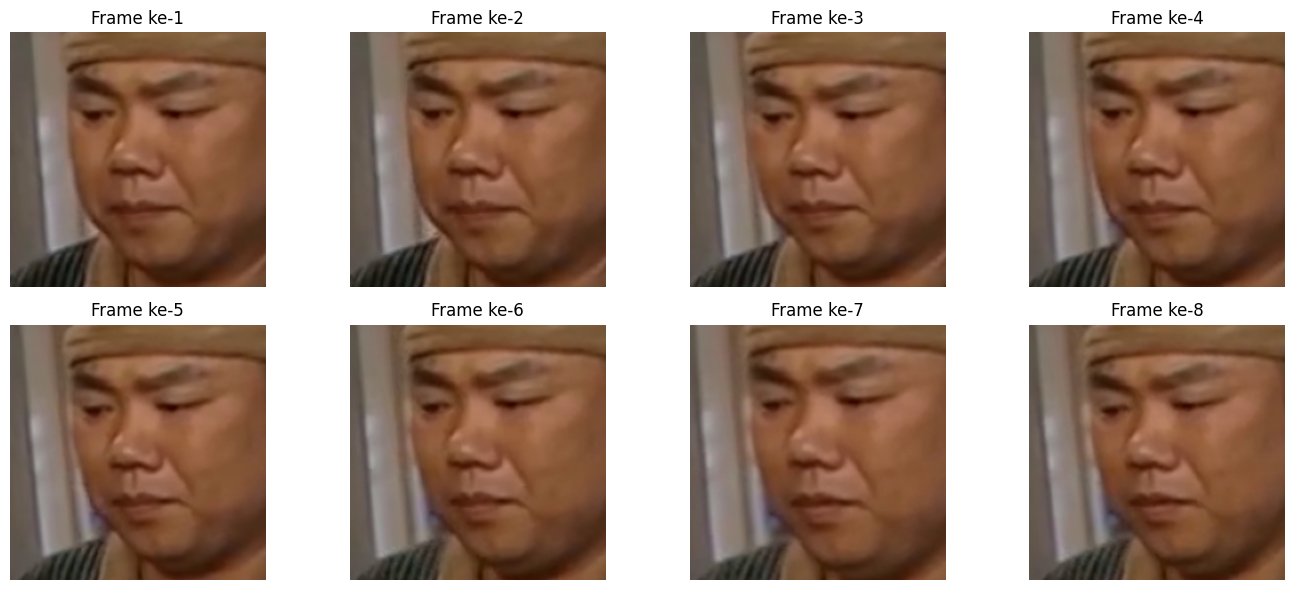

In [14]:
def denormalize_image(img_tensor, mean=NORM_MEAN, std=NORM_STD):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    return img

first_clip = sample_clips[0]
num_show = min(8, first_clip.shape[0])

fig, axes = plt.subplots(2, math.ceil(num_show / 2), figsize=(14, 6))
axes = np.array(axes).reshape(-1)

for i in range(num_show):
    axes[i].imshow(denormalize_image(first_clip[i]))
    axes[i].set_title(f"Frame ke-{i+1}")
    axes[i].axis("off")

for i in range(num_show, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### 15. Focal Loss & Labels

In [15]:
if CFG.num_frames % 2 != 0:
    raise ValueError(
        f"CFG.num_frames={CFG.num_frames} tidak kompatibel dengan tubelet temporal 2."
    )

id2label = {0: "real", 1: "fake"}
label2id = {"real": 0, "fake": 1}


class FocalLoss(nn.Module):
    """
    Focal Loss untuk klasifikasi multi-class berbasis logits.

    Pada notebook ini:
    - logits: [B, 2]
    - label : 0 = real, 1 = fake
    
    Rumus umum:
        FL = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2.0, alpha=None, reduction: str = "mean"):
        super().__init__()

        if gamma < 0:
            raise ValueError("gamma harus bernilai >= 0.")

        if reduction not in {"mean", "sum", "none"}:
            raise ValueError("reduction harus salah satu dari: 'mean', 'sum', atau 'none'.")

        self.gamma = gamma
        self.reduction = reduction

        if alpha is None:
            self.register_buffer("alpha", None)
        else:
            alpha = torch.as_tensor(alpha, dtype=torch.float32)
            self.register_buffer("alpha", alpha)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.long()

        log_probs = torch.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)

        target_indices = targets.unsqueeze(1)

        log_pt = log_probs.gather(1, target_indices).squeeze(1)
        pt = probs.gather(1, target_indices).squeeze(1)

        focal_factor = (1.0 - pt).pow(self.gamma)
        loss = -focal_factor * log_pt

        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            loss = alpha_t * loss

        if self.reduction == "mean":
            return loss.mean()

        if self.reduction == "sum":
            return loss.sum()

        return loss

### 16. Linear Decay Scheduler

In [16]:
class LinearDecayLR(_LRScheduler):
    def __init__(self, optimizer, n_epoch, start_decay, last_epoch=-1, booster=2):
        self.start_decay = start_decay
        self.n_epoch = n_epoch
        self.booster = booster
        super(LinearDecayLR, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        last_epoch = self.last_epoch
        n_epoch = self.n_epoch
        b_lr = self.base_lrs[-1]

        if last_epoch > 0:
            try:
                cur_lr = self.get_last_lr()
            except Exception:
                cur_lr = b_lr * self.booster

        start_decay = self.start_decay

        if last_epoch >= start_decay:
            lr = b_lr * self.booster - (b_lr * self.booster) / (n_epoch - start_decay) * (last_epoch - start_decay)
        else:
            if last_epoch < start_decay:
                lr = b_lr + (b_lr * self.booster - b_lr) / start_decay * last_epoch
            else:
                lr = cur_lr

        self._last_lr = [lr]
        print(f"Active Learning Rate --- {lr}")
        return [lr for _ in self.optimizer.param_groups]

### 17. Model Init & Optimizer

In [17]:
config = VideoMAEConfig.from_pretrained(
    str(MODEL_CHECKPOINT),
    local_files_only=True,
)

config.num_frames = CFG.num_frames
config.image_size = CFG.final_image_size
config.num_labels = 2
config.id2label = id2label
config.label2id = label2id

# Dropout ablation
config.hidden_dropout_prob = DROPOUT_RATE
config.attention_probs_dropout_prob = ATTENTION_DROPOUT_RATE

model = VideoMAEForVideoClassification.from_pretrained(
    str(MODEL_CHECKPOINT),
    config=config,
    ignore_mismatched_sizes=True,
    local_files_only=True,
)

model = model.to(DEVICE)

print("config.num_frames   :", model.config.num_frames)
print("config.image_size   :", model.config.image_size)
print("config.patch_size   :", model.config.patch_size)
print("config.tubelet_size :", model.config.tubelet_size)
print("config.hidden_dropout_prob          :", model.config.hidden_dropout_prob)
print("config.attention_probs_dropout_prob :", model.config.attention_probs_dropout_prob)

if USE_FOCAL_LOSS:
    if USE_FOCAL_ALPHA:
        label_counts_series = train_split_df["label"].astype(int).value_counts().sort_index()

        class_counts = torch.tensor(
            [
                label_counts_series.get(0, 0),
                label_counts_series.get(1, 0),
            ],
            dtype=torch.float32,
        )

        if torch.any(class_counts == 0):
            raise ValueError(
                f"Terdapat kelas dengan jumlah sampel 0 pada data latih: {class_counts.tolist()}"
            )

        focal_alpha = class_counts.sum() / (len(class_counts) * class_counts)
        focal_alpha = focal_alpha / focal_alpha.mean()

        print("Menggunakan Focal Loss dengan alpha otomatis.")
        print("Class counts [real, fake] :", class_counts.tolist())
        print("Focal alpha  [real, fake] :", focal_alpha.tolist())

    else:
        focal_alpha = None
        print("Menggunakan Focal Loss tanpa alpha.")

    criterion = FocalLoss(
        gamma=FOCAL_GAMMA,
        alpha=focal_alpha,
        reduction="mean",
    ).to(DEVICE)

else:
    criterion = nn.CrossEntropyLoss()
    print("Menggunakan CrossEntropyLoss.")


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)


scheduler = LinearDecayLR(
    optimizer=optimizer,
    n_epoch=EPOCHS,
    start_decay=SCHEDULER_START_DECAY,
    booster=SCHEDULER_BOOSTER,
)

scaler = torch.cuda.amp.GradScaler(enabled=USE_GRAD_SCALER)

print("Checkpoint aktif        :", MODEL_CHECKPOINT)
print("config.num_frames       :", model.config.num_frames)
print("config.image_size       :", model.config.image_size)
print("config.patch_size       :", model.config.patch_size)
print("config.tubelet_size     :", model.config.tubelet_size)
print("config.num_labels       :", model.config.num_labels)
print("classifier.out_features :", model.classifier.out_features)
print("Loss aktif              :", criterion.__class__.__name__)
print("USE_GRAD_SCALER         :", USE_GRAD_SCALER)
print("Optimizer          :", optimizer.__class__.__name__)
print("Base learning rate :", LR)
print("Weight decay       :", WEIGHT_DECAY)
print("Scheduler          :", SCHEDULER_NAME)
print("Start decay epoch  :", SCHEDULER_START_DECAY)
print("Scheduler booster  :", SCHEDULER_BOOSTER)
print("Max active LR      :", LR * SCHEDULER_BOOSTER)

Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at /workspace/wdf46f_runtime/kaggle_models/videomae-base-finetuned-ssv2 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([174, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([174]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


config.num_frames   : 16
config.image_size   : 224
config.patch_size   : 16
config.tubelet_size : 2
config.hidden_dropout_prob          : 0.0
config.attention_probs_dropout_prob : 0.0
Menggunakan CrossEntropyLoss.
Active Learning Rate --- 5e-05
Checkpoint aktif        : /workspace/wdf46f_runtime/kaggle_models/videomae-base-finetuned-ssv2
config.num_frames       : 16
config.image_size       : 224
config.patch_size       : 16
config.tubelet_size     : 2
config.num_labels       : 2
classifier.out_features : 2
Loss aktif              : CrossEntropyLoss
USE_GRAD_SCALER         : False
Optimizer          : AdamW
Base learning rate : 5e-05
Weight decay       : 0.0001
Scheduler          : LinearDecayLR
Start decay epoch  : 6
Scheduler booster  : 2
Max active LR      : 0.0001


### 18. Metrics

In [18]:
def compute_classification_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "precision_weighted": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "recall_weighted": recall_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "cm": cm,
        "y_pred": y_pred,
        "classification_report_text": classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=["real", "fake"],
            digits=4,
            zero_division=0,
        ),
        "classification_report_dict": classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=["real", "fake"],
            digits=4,
            zero_division=0,
            output_dict=True,
        ),
    }

    return metrics

### 19. Train/Eval Functions

In [19]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    scaler,
    device,
    epoch: int | None = None,
    total_epochs: int | None = None,
):
    model.train()

    running_loss = 0.0
    total_samples = 0
    all_y_true = []
    all_y_pred = []

    desc = f"Train {epoch:02d}/{total_epochs}" if epoch is not None else "Train"

    progress_bar = tqdm(
        loader,
        desc=desc,
        total=len(loader),
        dynamic_ncols=True,
        leave=False,
    )

    for batch_idx, (clips, labels, meta) in enumerate(progress_bar, start=1):
        batch_start = time.time()

        clips = clips.to(device, non_blocking=True)    # [B, T, C, H, W]
        labels = labels.to(device, non_blocking=True)  # [B]

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            outputs = model(pixel_values=clips)
            logits = outputs.logits
            loss = criterion(logits, labels)
            preds = torch.argmax(logits.detach().float(), dim=1)
            all_y_true.extend(labels.detach().cpu().numpy().tolist())
            all_y_pred.extend(preds.detach().cpu().numpy().tolist())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

        avg_loss = running_loss / max(total_samples, 1)
        batch_time = time.time() - batch_start

        progress_bar.set_postfix({
            "loss": f"{avg_loss:.4f}",
            "batch_s": f"{batch_time:.1f}",
        })

        del clips, labels, outputs, logits, loss

    train_metrics = compute_classification_metrics(all_y_true, all_y_pred)
    train_metrics["loss"] = running_loss / max(total_samples, 1)

    return train_metrics


@torch.no_grad()
def evaluate_clip_level(
    model,
    loader,
    criterion,
    device,
    epoch: int | None = None,
    total_epochs: int | None = None,
    split_name: str = "Valid",
):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_y_true = []
    all_y_pred = []
    all_probs = []
    all_clip_dirs = []

    if epoch is not None and total_epochs is not None:
        desc = f"{split_name} {epoch:02d}/{total_epochs}"
    else:
        desc = split_name

    progress_bar = tqdm(
        loader,
        desc=desc,
        total=len(loader),
        dynamic_ncols=True,
        leave=False,
    )

    for batch_idx, (clips, labels, meta) in enumerate(progress_bar, start=1):
        batch_start = time.time()

        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            outputs = model(pixel_values=clips)
            logits = outputs.logits
            loss = criterion(logits, labels)

        probs = torch.softmax(logits.float(), dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true = labels.detach().cpu().numpy()
        y_pred = preds.detach().cpu().numpy()
        prob_np = probs.detach().cpu().numpy()

        all_y_true.extend(y_true.tolist())
        all_y_pred.extend(y_pred.tolist())
        all_probs.append(prob_np)
        all_clip_dirs.extend(meta["clip_dir"])

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

        avg_loss = running_loss / max(total_samples, 1)
        batch_time = time.time() - batch_start

        progress_bar.set_postfix({
            "loss": f"{avg_loss:.4f}",
            "batch_s": f"{batch_time:.1f}",
        })

        del clips, labels, outputs, logits, loss, probs

    all_probs = np.concatenate(all_probs, axis=0)

    metric_dict = compute_classification_metrics(all_y_true, all_y_pred)
    metric_dict["loss"] = running_loss / max(total_samples, 1)
    metric_dict["y_true"] = np.array(all_y_true)
    metric_dict["y_pred"] = np.array(all_y_pred)
    metric_dict["y_prob_real"] = all_probs[:, 0]
    metric_dict["y_prob_fake"] = all_probs[:, 1]
    metric_dict["clip_dirs"] = list(all_clip_dirs)

    return metric_dict

### 20. W&B Init

In [20]:
# INISIALISASI WEIGHTS & BIASES
wandb_run = None

def setup_wandb_login():
    if not USE_WANDB:
        return

    os.environ["WANDB_MODE"] = WANDB_MODE
    print(f"W&B mode: {os.environ['WANDB_MODE']}")

def build_wandb_config():
    return {
        "experiment_code": CFG.code,
        "experiment_description": CFG.description,
        "model_kind": MODEL_KIND,
        "num_classes": 2,
        "class_0": "real",
        "class_1": "fake",
        "source_clip_len": SOURCE_CLIP_LEN,
        "num_frames": CFG.num_frames,
        "stride": CFG.stride,
        "final_image_size": CFG.final_image_size,
        "aug_geometry_oneof_prob": AUG_GEOMETRY_ONEOF_PROB,
        "aug_horizontal_flip": AUG_PROB_HFLIP,
        "aug_crop_limit": AUG_CROP_LIMIT,
        "aug_crop_prob": AUG_CROP_PROB,
        "aug_scale_limit": AUG_SCALE_LIMIT,
        "aug_scale_prob": AUG_SCALE_PROB,
        "aug_colorjitter_prob": AUG_COLORJITTER_PROB,
        "aug_colorjitter_brightness": AUG_COLORJITTER_BRIGHTNESS,
        "aug_colorjitter_contrast": AUG_COLORJITTER_CONTRAST,
        "aug_colorjitter_saturation": AUG_COLORJITTER_SATURATION,
        "aug_colorjitter_hue": AUG_COLORJITTER_HUE,
        "aug_blur_or_noise_oneof_prob": AUG_BLUR_OR_NOISE_ONEOF_PROB,
        "aug_gaussian_blur_prob": AUG_GAUSSIAN_BLUR_PROB,
        "aug_gaussian_blur_limit": AUG_GAUSSIAN_BLUR_LIMIT,
        "aug_gaussnoise_prob": AUG_GAUSSNOISE_PROB,
        "aug_gaussnoise_var_limit": AUG_GAUSSNOISE_VAR_LIMIT,
        "downscale_first": CFG.downscale_first,
        "batch_size_clips": BATCH_SIZE_CLIPS,
        "epochs": EPOCHS,
        "learning_rate": LR,
        "weight_decay": WEIGHT_DECAY,
        "dropout_rate": DROPOUT_RATE,
        "attention_dropout_rate": ATTENTION_DROPOUT_RATE,
        "drop_path_rate": DROP_PATH_RATE,
        "optimizer": optimizer.__class__.__name__,
        "scheduler": SCHEDULER_NAME,
        "scheduler_start_decay": SCHEDULER_START_DECAY,
        "scheduler_booster": SCHEDULER_BOOSTER,
        "base_learning_rate": LR,
        "max_active_learning_rate": LR * SCHEDULER_BOOSTER,
        "use_early_stopping": USE_EARLY_STOPPING,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE if USE_EARLY_STOPPING else None,
        "loss_name": criterion.__class__.__name__,
        "use_focal_loss": USE_FOCAL_LOSS,
        "focal_gamma": FOCAL_GAMMA if USE_FOCAL_LOSS else None,
        "use_focal_alpha": USE_FOCAL_ALPHA if USE_FOCAL_LOSS else None,
        "train_size": len(train_dataset),
        "val_size": len(val_dataset),
        "test_size": len(test_dataset),
        "normalization_mean": NORM_MEAN,
        "normalization_std": NORM_STD,
        "checkpoint_selected_by": "val_accuracy",
        "evaluation_level": "clip_level",
    }


if USE_WANDB:
    setup_wandb_login()

    if wandb.run is not None:
        wandb.finish()

    wandb_run = wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=WANDB_RUN_NAME,
        group=WANDB_GROUP,
        tags=WANDB_TAGS,
        config=build_wandb_config(),
        dir=str(OUTPUT_DIR),
        reinit=True,
    )

    wandb_run.define_metric("epoch")
    wandb_run.define_metric("train/*", step_metric="epoch")
    wandb_run.define_metric("valid/*", step_metric="epoch")
    wandb_run.define_metric("lr", step_metric="epoch")
    wandb_run.define_metric("time/*", step_metric="epoch")
    wandb_run.define_metric("test/*")

    print("W&B run aktif:", wandb_run.name)
else:
    print("W&B dinonaktifkan.")

W&B mode: online


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: afenmarbun (afenmarbun-institut-teknologi-sumatera) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


W&B run aktif: E01_spatiotemporal_videomae_videomae-base-finetuned-ssv2


### 21. Training Loop & Checkpoint

In [21]:
history = []
best_state = None
best_epoch = 0
best_val_accuracy = float("-inf")
best_val_loss_at_best_acc = None
patience_counter = 0

checkpoint_path = OUTPUT_DIR / f"best_{CFG.code}_videomae.pt"

start_time = time.time()

print("Mulai training...", flush=True)
print("Experiment code :", CFG.code, flush=True)
print("Device          :", DEVICE, flush=True)
print("Checkpoint path :", checkpoint_path, flush=True)
print("Jumlah epoch    :", EPOCHS, flush=True)
print("Train batches   :", len(train_loader), flush=True)
print("Valid batches   :", len(val_loader), flush=True)

epoch_bar = tqdm(
    range(1, EPOCHS + 1),
    desc=f"Training {CFG.code}",
    total=EPOCHS,
    dynamic_ncols=True,
)

for epoch in epoch_bar:
    epoch_start = time.time()

    print(f"\n[{CFG.code}] Mulai epoch {epoch:02d}/{EPOCHS}", flush=True)

    train_result = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        scaler=scaler,
        device=DEVICE,
        epoch=epoch,
        total_epochs=EPOCHS,
    )

    train_loss = train_result["loss"]

    val_result = evaluate_clip_level(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE,
        epoch=epoch,
        total_epochs=EPOCHS,
        split_name="Valid",
    )

    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()
    epoch_time_sec = time.time() - epoch_start

    row = {
        "epoch": int(epoch),
        "train_loss": float(train_loss),
        "train_accuracy": float(train_result["accuracy"]),
        "train_precision_macro": float(train_result["precision_macro"]),
        "train_recall_macro": float(train_result["recall_macro"]),
        "train_f1_macro": float(train_result["f1_macro"]),
        "train_precision_weighted": float(train_result["precision_weighted"]),
        "train_recall_weighted": float(train_result["recall_weighted"]),
        "train_f1_weighted": float(train_result["f1_weighted"]),

        "val_loss": float(val_result["loss"]),
        "val_accuracy": float(val_result["accuracy"]),
        "val_precision_macro": float(val_result["precision_macro"]),
        "val_recall_macro": float(val_result["recall_macro"]),
        "val_f1_macro": float(val_result["f1_macro"]),
        "val_precision_weighted": float(val_result["precision_weighted"]),
        "val_recall_weighted": float(val_result["recall_weighted"]),
        "val_f1_weighted": float(val_result["f1_weighted"]),

        "lr": float(optimizer.param_groups[0]["lr"]),
        "epoch_time_sec": float(epoch_time_sec),
    }
    history.append(row)
    
    if wandb_run is not None:
        wandb_run.log(
            {
                "epoch": row["epoch"],

                "train/loss": row["train_loss"],
                "train/accuracy": row["train_accuracy"],
                "train/precision_macro": row["train_precision_macro"],
                "train/recall_macro": row["train_recall_macro"],
                "train/f1_macro": row["train_f1_macro"],
                "train/precision_weighted": row["train_precision_weighted"],
                "train/recall_weighted": row["train_recall_weighted"],
                "train/f1_weighted": row["train_f1_weighted"],

                "valid/loss": row["val_loss"],
                "valid/accuracy": row["val_accuracy"],
                "valid/precision_macro": row["val_precision_macro"],
                "valid/recall_macro": row["val_recall_macro"],
                "valid/f1_macro": row["val_f1_macro"],
                "valid/precision_weighted": row["val_precision_weighted"],
                "valid/recall_weighted": row["val_recall_weighted"],
                "valid/f1_weighted": row["val_f1_weighted"],

                "lr": row["lr"],
                "time/epoch_sec": row["epoch_time_sec"],
            },
            step=epoch,
        )

    epoch_bar.set_postfix({
        "train_loss": f"{train_loss:.4f}",
        "val_loss": f"{val_result['loss']:.4f}",
        "val_f1_macro": f"{val_result['f1_macro']:.4f}",
    })

    print(
        f"[{CFG.code}] Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"train_acc={train_result['accuracy']:.4f} | "
        f"train_f1_macro={train_result['f1_macro']:.4f} | "
        f"val_loss={val_result['loss']:.4f} | "
        f"val_acc={val_result['accuracy']:.4f} | "
        f"val_f1_macro={val_result['f1_macro']:.4f} | "
        f"epoch_time={epoch_time_sec/60:.2f} menit",
        flush=True,
    )

    current_val_accuracy = float(val_result["accuracy"])

    if current_val_accuracy > best_val_accuracy:
        best_val_accuracy = current_val_accuracy
        best_val_loss_at_best_acc = float(val_result["loss"])
        best_epoch = int(epoch)
        patience_counter = 0

        model_state_cpu = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

        best_state = {
            "epoch": int(epoch),
            "experiment_code": str(CFG.code),
            "experiment_config": dict(CFG.__dict__),
            "model_checkpoint": str(MODEL_CHECKPOINT),
            "checkpoint_selected_by": "val_accuracy",

            "loss_name": str(criterion.__class__.__name__),
            "use_focal_loss": bool(USE_FOCAL_LOSS),
            "focal_gamma": float(FOCAL_GAMMA) if USE_FOCAL_LOSS else None,
            "use_focal_alpha": bool(USE_FOCAL_ALPHA) if USE_FOCAL_LOSS else None,

            "model_state_dict": model_state_cpu,
            
            "best_val_accuracy": float(val_result["accuracy"]),
            "best_val_loss": float(val_result["loss"]),
            "best_val_precision_macro": float(val_result["precision_macro"]),
            "best_val_recall_macro": float(val_result["recall_macro"]),
            "best_val_f1_macro": float(val_result["f1_macro"]),
            "best_val_precision_weighted": float(val_result["precision_weighted"]),
            "best_val_recall_weighted": float(val_result["recall_weighted"]),
            "best_val_f1_weighted": float(val_result["f1_weighted"]),
        }

        torch.save(best_state, checkpoint_path)

        if wandb_run is not None:
            wandb_run.summary["best_epoch"] = int(epoch)
            wandb_run.summary["best/val_accuracy"] = float(val_result["accuracy"])
            wandb_run.summary["best/val_loss"] = float(val_result["loss"])
            wandb_run.summary["best/val_precision_macro"] = float(val_result["precision_macro"])
            wandb_run.summary["best/val_recall_macro"] = float(val_result["recall_macro"])
            wandb_run.summary["best/val_f1_macro"] = float(val_result["f1_macro"])
            wandb_run.summary["best/val_precision_weighted"] = float(val_result["precision_weighted"])
            wandb_run.summary["best/val_recall_weighted"] = float(val_result["recall_weighted"])
            wandb_run.summary["best/val_f1_weighted"] = float(val_result["f1_weighted"])

        print(
            f"  -> checkpoint terbaik disimpan berdasarkan "
            f"val_accuracy={best_val_accuracy:.4f}: {checkpoint_path}",
            flush=True,
        )

    else:
        if USE_EARLY_STOPPING:
            patience_counter += 1

            print(
                f"  -> val_accuracy tidak membaik, "
                f"patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}",
                flush=True,
            )

            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print("\nEarly stopping aktif.", flush=True)
                break

        else:
            print(
                "  -> val_accuracy tidak membaik; early stopping dinonaktifkan, training tetap dilanjutkan.",
                flush=True,
            )

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

total_time = time.time() - start_time

print(f"\nTraining selesai dalam {total_time/60:.2f} menit.", flush=True)
print(f"Best epoch        : {best_epoch}", flush=True)
print(f"Best val_accuracy : {best_val_accuracy:.4f}", flush=True)
print(f"Val loss at best  : {best_val_loss_at_best_acc:.4f}", flush=True)

history_df = pd.DataFrame(history)

history_df = history_df[
    [
        "epoch",
        "train_loss",
        "train_accuracy",
        "train_precision_macro",
        "train_recall_macro",
        "train_f1_macro",
        "train_precision_weighted",
        "train_recall_weighted",
        "train_f1_weighted",

        "val_loss",
        "val_accuracy",
        "val_precision_macro",
        "val_recall_macro",
        "val_f1_macro",
        "val_precision_weighted",
        "val_recall_weighted",
        "val_f1_weighted",

        "lr",
        "epoch_time_sec",
    ]
]

history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

if wandb_run is not None:
    wandb_run.log(
        {
            "training/history_table": wandb.Table(dataframe=history_df)
        },
        step=int(history_df["epoch"].max()),
    )

display(history_df.reset_index(drop=True))

Mulai training...
Experiment code : E01
Device          : cuda
Checkpoint path : /workspace/experiments/spatiotemporal_videomae/E01/best_E01_videomae.pt
Jumlah epoch    : 25
Train batches   : 485
Valid batches   : 112


Training E01:   0% 0/25 [00:00<?, ?it/s]


[E01] Mulai epoch 01/25


Train 01/25:   0% 0/485 [00:04<?, ?it/s]

Valid 01/25:   0% 0/112 [00:00<?, ?it/s]

...

Active Learning Rate --- 5.263157894736843e-06
[E01] Epoch 24 | train_loss=0.3069 | train_acc=0.8408 | train_f1_macro=0.8007 | val_loss=0.3266 | val_acc=0.9107 | val_f1_macro=0.9058 | epoch_time=3.04 menit
  -> checkpoint terbaik disimpan berdasarkan val_accuracy=0.9107: /workspace/experiments/spatiotemporal_videomae/E01/best_E01_videomae.pt

[E01] Mulai epoch 25/25


Train 25/25:   0% 0/485 [00:00<?, ?it/s]

Valid 25/25:   0% 0/112 [00:00<?, ?it/s]

Active Learning Rate --- 0.0
[E01] Epoch 25 | train_loss=0.3005 | train_acc=0.8473 | train_f1_macro=0.8098 | val_loss=0.3389 | val_acc=0.9059 | val_f1_macro=0.9008 | epoch_time=3.03 menit
  -> val_accuracy tidak membaik; early stopping dinonaktifkan, training tetap dilanjutkan.

Training selesai dalam 75.81 menit.
Best epoch        : 24
Best val_accuracy : 0.9107
Val loss at best  : 0.3266


,epoch,train_loss,train_accuracy,train_precision_macro,train_recall_macro,train_f1_macro,train_precision_weighted,train_recall_weighted,train_f1_weighted,val_loss,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_precision_weighted,val_recall_weighted,val_f1_weighted,lr,epoch_time_sec
0,1,0.605589,0.668968,0.623617,0.559775,0.541052,0.642150,0.668968,0.615272,0.556173,0.700644,0.685954,0.689001,0.687212,0.703569,0.700644,0.701860,0.000058,186.296188
1,2,0.558540,0.704645,0.684553,0.613170,0.613088,0.693786,0.704645,0.670742,0.603517,0.761971,0.757176,0.729421,0.736867,0.759942,0.761971,0.755235,0.000067,171.201826
2,3,0.537498,0.721613,0.711725,0.634403,0.638706,0.716373,0.721613,0.691722,0.482591,0.781574,0.771868,0.761682,0.765718,0.779320,0.781574,0.779492,0.000075,171.944809
3,4,0.523296,0.732581,0.724454,0.651130,0.658662,0.728441,0.732581,0.707319,0.448113,0.811537,0.820492,0.778387,0.789646,0.815665,0.811537,0.804981,0.000083,184.271072
4,5,0.513593,0.736645,0.734155,0.653412,0.661209,0.735352,0.736645,0.710180,0.465589,0.804817,0.815535,0.769303,0.780801,0.809980,0.804817,0.797197,0.000092,186.011015
5,6,0.504255,0.743290,0.747088,0.659677,0.668481,0.745281,0.743290,0.716722,0.398844,0.828339,0.835676,0.799294,0.810199,0.831450,0.828339,0.823459,0.000100,183.205195
6,7,0.499619,0.745548,0.751057,0.662103,0.671319,0.748437,0.745548,0.719166,0.455289,0.822179,0.811990,0.819344,0.814945,0.825580,0.822179,0.823213,0.000095,181.684907
7,8,0.485894,0.757161,0.762943,0.679324,0.691193,0.760077,0.757161,0.734914,0.383572,0.825259,0.835894,0.793580,0.805391,0.830075,0.825259,0.819443,0.000089,182.231708
8,9,0.462576,0.770516,0.781777,0.695567,0.709688,0.776115,0.770516,0.750394,0.383069,0.847942,0.841441,0.836090,0.838533,0.847162,0.847942,0.847341,0.000084,181.857124
9,10,0.455002,0.766516,0.779990,0.688623,0.702024,0.773377,0.766516,0.744488,0.414935,0.828059,0.822392,0.811203,0.815807,0.826811,0.828059,0.826543,0.000079,182.399698


### 22. Training Curves

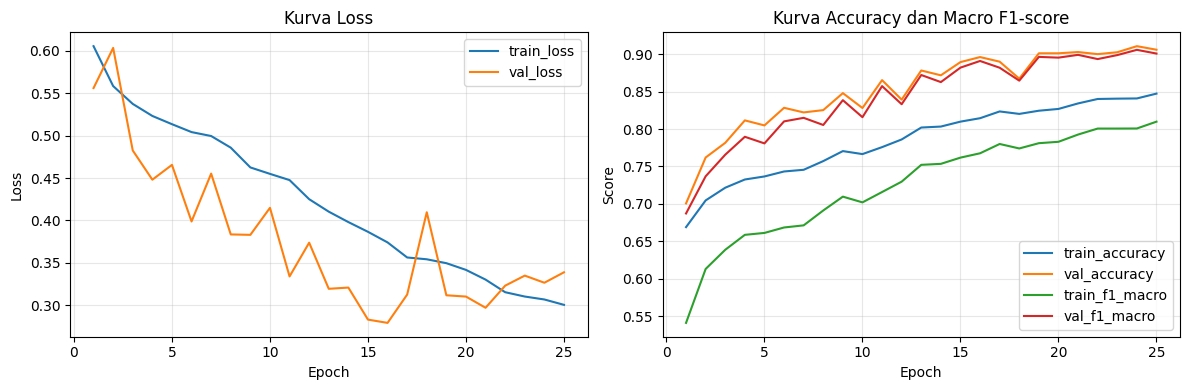

Plot history disimpan: /workspace/experiments/spatiotemporal_videomae/E01/training_history.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].set_title("Kurva Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="train_accuracy")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="val_accuracy")
axes[1].plot(history_df["epoch"], history_df["train_f1_macro"], label="train_f1_macro")
axes[1].plot(history_df["epoch"], history_df["val_f1_macro"], label="val_f1_macro")
axes[1].set_title("Kurva Accuracy dan Macro F1-score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

history_plot_path = OUTPUT_DIR / "training_history.png"
plt.savefig(history_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Plot history disimpan:", history_plot_path)

### 23. Training Summary

In [23]:
if best_state is None:
    raise RuntimeError(
        "best_state masih None. Artinya belum ada checkpoint yang berhasil disimpan."
    )

summary_df = pd.DataFrame([{
    "experiment_code": CFG.code,
    "experiment_description": CFG.description,
    "model_checkpoint": str(MODEL_CHECKPOINT),
    "checkpoint_path": str(checkpoint_path),
    "num_frames": CFG.num_frames,
    "stride": CFG.stride,
    "final_image_size": CFG.final_image_size,
    "downscale_first": CFG.downscale_first,
    "batch_size_clips": BATCH_SIZE_CLIPS,
    "checkpoint_selected_by": best_state.get("checkpoint_selected_by", "val_accuracy"),
    "loss_name": best_state.get("loss_name", criterion.__class__.__name__),
    "use_focal_loss": best_state.get("use_focal_loss", USE_FOCAL_LOSS),
    "focal_gamma": best_state.get("focal_gamma", FOCAL_GAMMA if USE_FOCAL_LOSS else None),
    "use_focal_alpha": best_state.get("use_focal_alpha", USE_FOCAL_ALPHA if USE_FOCAL_LOSS else None),
    "best_epoch": best_state["epoch"],
    "best_val_accuracy": best_state["best_val_accuracy"],
    "best_val_loss": best_state["best_val_loss"],
    "best_val_precision_macro": best_state["best_val_precision_macro"],
    "best_val_recall_macro": best_state["best_val_recall_macro"],
    "best_val_f1_macro": best_state["best_val_f1_macro"],
    "best_val_precision_weighted": best_state["best_val_precision_weighted"],
    "best_val_recall_weighted": best_state["best_val_recall_weighted"],
    "best_val_f1_weighted": best_state["best_val_f1_weighted"],
}])

summary_df.to_csv(OUTPUT_DIR / "training_summary.csv", index=False)

if wandb_run is not None:
    wandb_run.log({
        "training/summary_table": wandb.Table(dataframe=summary_df)
    })

print("Training summary:")
display(summary_df)

Training summary:


,experiment_code,experiment_description,model_checkpoint,checkpoint_path,num_frames,stride,final_image_size,downscale_first,batch_size_clips,checkpoint_selected_by,...,use_focal_alpha,best_epoch,best_val_accuracy,best_val_loss,best_val_precision_macro,best_val_recall_macro,best_val_f1_macro,best_val_precision_weighted,best_val_recall_weighted,best_val_f1_weighted
0,E01,"Konfigurasi dasar dengan resolusi 224 x 224, 1...",/workspace/wdf46f_runtime/kaggle_models/videom...,/workspace/experiments/spatiotemporal_videomae...,16,3,224,None,32,val_accuracy,...,None,24,0.910669,0.326595,0.90616,0.905395,0.905773,0.910592,0.910669,0.910627


### 24. Final Test Evaluation

In [24]:
# FINAL TESTING PADA DATA TEST
test_output_dir = OUTPUT_DIR / "test_results"
test_output_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = OUTPUT_DIR / f"best_{CFG.code}_videomae.pt"

if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Checkpoint terbaik tidak ditemukan: {checkpoint_path}\n"
        "Pastikan cell training sudah dijalankan sampai checkpoint tersimpan."
    )

print("Memuat checkpoint terbaik:")
print(checkpoint_path)

try:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )
except TypeError:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
    )

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print("\nInformasi checkpoint:")
print("Experiment code       :", checkpoint.get("experiment_code"))
print("Best epoch            :", checkpoint.get("epoch"))
print("Selected by           :", checkpoint.get("checkpoint_selected_by"))
print("Best val accuracy     :", checkpoint.get("best_val_accuracy"))
print("Best val F1 macro     :", checkpoint.get("best_val_f1_macro"))
print("Best val precision macro:", checkpoint.get("best_val_precision_macro"))
print("Best val recall macro :", checkpoint.get("best_val_recall_macro"))
print("\nMulai evaluasi pada data test...")

test_result = evaluate_clip_level(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
    split_name="Test",
)

test_metrics = {
    "experiment_code": CFG.code,
    "description": CFG.description,
    "checkpoint_path": str(checkpoint_path),
    "best_epoch": int(checkpoint.get("epoch")),
    "checkpoint_selected_by": checkpoint.get("checkpoint_selected_by"),
    "test_loss": float(test_result["loss"]),
    "test_accuracy": float(test_result["accuracy"]),
    "test_precision_macro": float(test_result["precision_macro"]),
    "test_recall_macro": float(test_result["recall_macro"]),
    "test_f1_macro": float(test_result["f1_macro"]),
    "test_precision_weighted": float(test_result["precision_weighted"]),
    "test_recall_weighted": float(test_result["recall_weighted"]),
    "test_f1_weighted": float(test_result["f1_weighted"]),
}

print("\n HASIL FINAL TEST : ")
print(f"Test loss                : {test_metrics['test_loss']:.4f}")
print(f"Test accuracy            : {test_metrics['test_accuracy']:.4f}")
print(f"Test precision macro     : {test_metrics['test_precision_macro']:.4f}")
print(f"Test recall macro        : {test_metrics['test_recall_macro']:.4f}")
print(f"Test F1-score macro      : {test_metrics['test_f1_macro']:.4f}")
print(f"Test precision weighted  : {test_metrics['test_precision_weighted']:.4f}")
print(f"Test recall weighted     : {test_metrics['test_recall_weighted']:.4f}")
print(f"Test F1-score weighted   : {test_metrics['test_f1_weighted']:.4f}")

print("\nConfusion Matrix")
print("Baris  : label aktual [real, fake]")
print("Kolom  : label prediksi [real, fake]")
print(test_result["cm"])


# SIMPAN METRIK TEST
test_metrics_csv_path = test_output_dir / "test_metrics.csv"
test_metrics_json_path = test_output_dir / "test_metrics.json"

pd.DataFrame([test_metrics]).to_csv(test_metrics_csv_path, index=False)
with open(test_metrics_json_path, "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2)


# SIMPAN PREDIKSI PER KLIP
test_pred_df = pd.DataFrame({
    "clip_dir": test_result["clip_dirs"],
    "y_true": test_result["y_true"].astype(int),
    "y_pred": test_result["y_pred"].astype(int),
    "y_prob_real": test_result["y_prob_real"].astype(float),
    "y_prob_fake": test_result["y_prob_fake"].astype(float),
})

test_pred_df["y_true_label"] = test_pred_df["y_true"].map(IDX_TO_CLASS)
test_pred_df["y_pred_label"] = test_pred_df["y_pred"].map(IDX_TO_CLASS)
test_pred_df["is_correct"] = test_pred_df["y_true"] == test_pred_df["y_pred"]

classification_report_df = pd.DataFrame(test_result["classification_report_dict"]).T
classification_report_path = test_output_dir / "test_classification_report.csv"
classification_report_df.to_csv(classification_report_path)

if wandb_run is not None:
    wandb_run.log({
        "test/classification_report": wandb.Table(
            dataframe=classification_report_df.reset_index()
        )
    })

print("Classification report:", classification_report_path)
print("\nClassification Report")
print(test_result["classification_report_text"])

test_predictions_csv_path = test_output_dir / "test_predictions_clip_level.csv"
test_pred_df.to_csv(test_predictions_csv_path, index=False)

if wandb_run is not None:
    wandb_run.log({
        "test/predictions_clip_level_sample": wandb.Table(
            dataframe=test_pred_df.head(1000)
        )
    })

print("\nFile hasil test disimpan:")
print("-", test_metrics_csv_path)
print("-", test_metrics_json_path)
print("-", test_predictions_csv_path)

display(test_pred_df.head())

Memuat checkpoint terbaik:
/workspace/experiments/spatiotemporal_videomae/E01/best_E01_videomae.pt

Informasi checkpoint:
Experiment code       : E01
Best epoch            : 24
Selected by           : val_accuracy
Best val accuracy     : 0.9106692803136376
Best val F1 macro     : 0.9057732592356391
Best val precision macro: 0.9061597946679913
Best val recall macro : 0.9053947873825119

Mulai evaluasi pada data test...


Test:   0% 0/101 [00:07<?, ?it/s]


 HASIL FINAL TEST : 
Test loss                : 0.7131
Test accuracy            : 0.8144
Test precision macro     : 0.7925
Test recall macro        : 0.7938
Test F1-score macro      : 0.7931
Test precision weighted  : 0.8148
Test recall weighted     : 0.8144
Test F1-score weighted   : 0.8146

Confusion Matrix
Baris  : label aktual [real, fake]
Kolom  : label prediksi [real, fake]
[[ 798  295]
 [ 305 1834]]
Classification report: /workspace/experiments/spatiotemporal_videomae/E01/test_results/test_classification_report.csv

Classification Report
              precision    recall  f1-score   support

        real     0.7235    0.7301    0.7268      1093
        fake     0.8614    0.8574    0.8594      2139

    accuracy                         0.8144      3232
   macro avg     0.7925    0.7938    0.7931      3232
weighted avg     0.8148    0.8144    0.8146      3232


File hasil test disimpan:
- /workspace/experiments/spatiotemporal_videomae/E01/test_results/test_metrics.csv
- /workspac

,clip_dir,y_true,y_pred,y_prob_real,y_prob_fake,y_true_label,y_pred_label,is_correct
0,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,0,0.999301,0.000699,real,real,True
1,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,0,0.998633,0.001367,real,real,True
2,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,0,0.999103,0.000897,real,real,True
3,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,0,0.990441,0.009559,real,real,True
4,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,0,0.999680,0.000320,real,real,True


### 25. W&B Test Logging

In [25]:
if wandb_run is not None:
    wandb_run.log({
        "test/loss": test_metrics["test_loss"],
        "test/accuracy": test_metrics["test_accuracy"],
        "test/precision_macro": test_metrics["test_precision_macro"],
        "test/recall_macro": test_metrics["test_recall_macro"],
        "test/f1_macro": test_metrics["test_f1_macro"],
        "test/precision_weighted": test_metrics["test_precision_weighted"],
        "test/recall_weighted": test_metrics["test_recall_weighted"],
        "test/f1_weighted": test_metrics["test_f1_weighted"],
    })

    wandb_run.summary["test/loss"] = test_metrics["test_loss"]
    wandb_run.summary["test/accuracy"] = test_metrics["test_accuracy"]
    wandb_run.summary["test/precision_macro"] = test_metrics["test_precision_macro"]
    wandb_run.summary["test/recall_macro"] = test_metrics["test_recall_macro"]
    wandb_run.summary["test/f1_macro"] = test_metrics["test_f1_macro"]
    wandb_run.summary["test/precision_weighted"] = test_metrics["test_precision_weighted"]
    wandb_run.summary["test/recall_weighted"] = test_metrics["test_recall_weighted"]
    wandb_run.summary["test/f1_weighted"] = test_metrics["test_f1_weighted"]

### 26. Confusion Matrix Plot

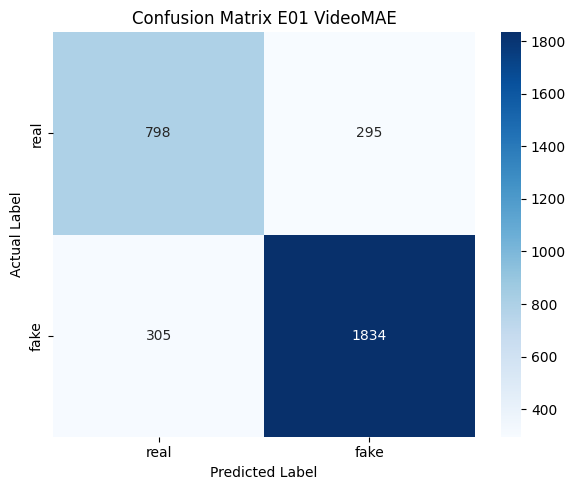

Confusion matrix disimpan: /workspace/experiments/spatiotemporal_videomae/E01/test_results/test_confusion_matrix.png


In [26]:
# VISUALISASI HASIL TESTING

cm = test_result["cm"]
class_names = [IDX_TO_CLASS[i] for i in sorted(IDX_TO_CLASS.keys())]  # ["real", "fake"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(f"Confusion Matrix {CFG.code} VideoMAE")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()

confusion_matrix_path = test_output_dir / "test_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=200, bbox_inches="tight")
plt.show()

if wandb_run is not None:
    wandb_run.log({
        "test/confusion_matrix": wandb.Image(str(confusion_matrix_path))
    })

print("Confusion matrix disimpan:", confusion_matrix_path)

### 27. Misclassified Analysis

In [27]:
# ANALISIS SAMPEL YANG SALAH PREDIKSI

misclassified_df = test_pred_df[test_pred_df["is_correct"] == False].copy()

print("Jumlah seluruh klip test       :", len(test_pred_df))
print("Jumlah salah prediksi          :", len(misclassified_df))
print("Persentase salah prediksi (%)  :", 100 * len(misclassified_df) / max(len(test_pred_df), 1))

display(
    misclassified_df.sort_values(
        by="y_prob_fake",
        ascending=False,
    ).head(30)
)

misclassified_csv_path = test_output_dir / "test_misclassified_clip_level.csv"
misclassified_df.to_csv(misclassified_csv_path, index=False)

print("Data salah prediksi disimpan:", misclassified_csv_path)

Jumlah seluruh klip test       : 3232
Jumlah salah prediksi          : 600
Persentase salah prediksi (%)  : 18.564356435643564


,clip_dir,y_true,y_pred,y_prob_real,y_prob_fake,y_true_label,y_pred_label,is_correct
683,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000077,0.999923,real,fake,False
660,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000096,0.999904,real,fake,False
532,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000131,0.999869,real,fake,False
533,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000131,0.999869,real,fake,False
685,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000140,0.999860,real,fake,False
423,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000158,0.999842,real,fake,False
424,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000163,0.999837,real,fake,False
654,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000169,0.999831,real,fake,False
682,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000261,0.999739,real,fake,False
644,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000287,0.999713,real,fake,False


Data salah prediksi disimpan: /workspace/experiments/spatiotemporal_videomae/E01/test_results/test_misclassified_clip_level.csv


### 28. Grad-CAM Visualization

Memuat checkpoint terbaik untuk Grad-CAM:
/workspace/experiments/spatiotemporal_videomae/E01/best_E01_videomae.pt
Checkpoint berhasil dimuat.
Best epoch        : 24
Best val accuracy : 0.9106692803136376
Format input Grad-CAM yang digunakan:
[B, T*C, H, W] = [1, 48, 224, 224]
Target layer Grad-CAM:
LayerNorm((768,), eps=1e-12, elementwise_affine=True)

Validasi konfigurasi token Grad-CAM:
num_frames        : 16
tubelet_size      : 2
temporal_patches  : 8
patch_size        : 16
grid_h x grid_w   : 14 x 14
expected_tokens   : 1568

Sample index      : 0
Clip dir          : /workspace/wdf46f_runtime/wilddeepfake-46f/wilddeepfake_46f_merged_v5/real_test/104/10_0
True label        : real
Pred label        : real
Target Grad-CAM   : real
Prob real         : 0.9992935657501221
Prob fake         : 0.0007063765660859644
Sampled indices   : [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45]


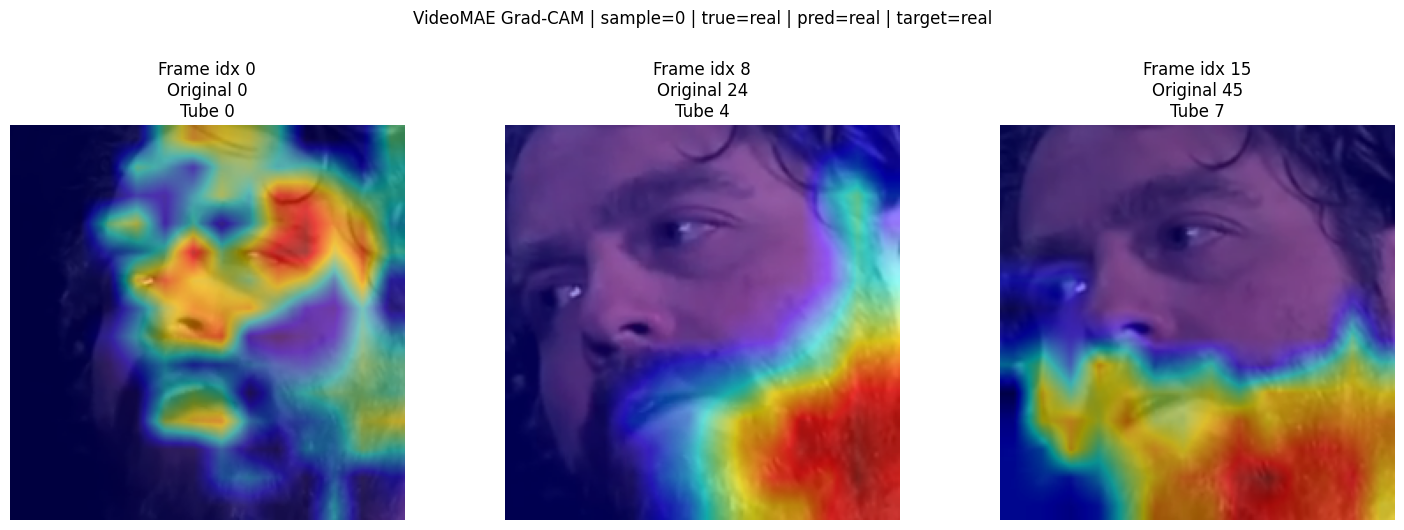


Sample index      : 1
Clip dir          : /workspace/wdf46f_runtime/wilddeepfake-46f/wilddeepfake_46f_merged_v5/real_test/104/10_1
True label        : real
Pred label        : real
Target Grad-CAM   : real
Prob real         : 0.998645007610321
Prob fake         : 0.0013550423318520188
Sampled indices   : [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45]


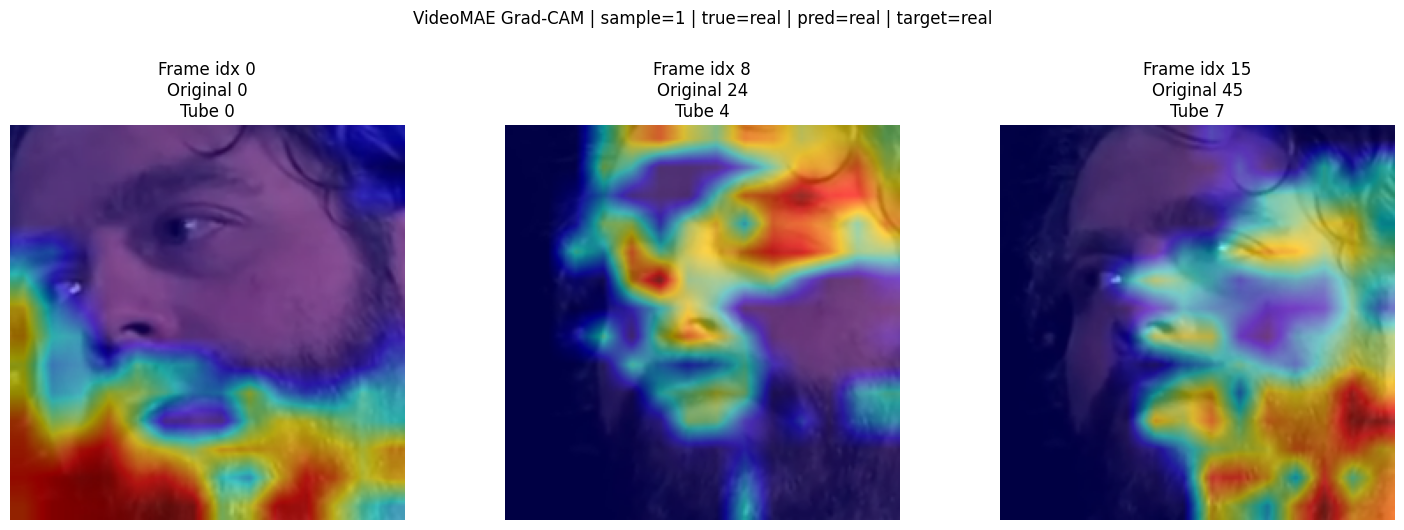


Sample index      : 2
Clip dir          : /workspace/wdf46f_runtime/wilddeepfake-46f/wilddeepfake_46f_merged_v5/real_test/104/13_0
True label        : real
Pred label        : real
Target Grad-CAM   : real
Prob real         : 0.9991093277931213
Prob fake         : 0.0008906492730602622
Sampled indices   : [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45]


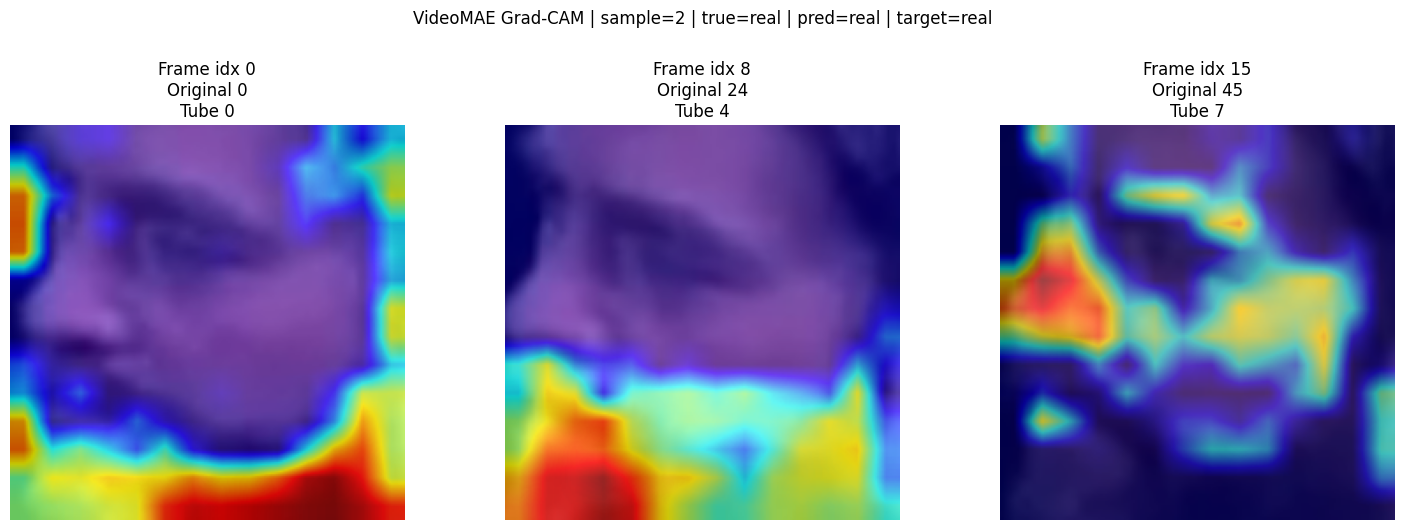


Grad-CAM selesai.
Folder output: /workspace/experiments/spatiotemporal_videomae/E01/gradcam_results


In [28]:

# GRAD-CAM UNTUK MODEL SPASIOTEMPORAL VIDEOMAE
# Catatan:
# VideoMAE memproses token spasiotemporal.
# Dengan tubelet_size=2, dua frame yang berdekatan berada pada temporal tube yang sama.
# Oleh karena itu, heatmap frame 0 dan 1 dapat merujuk ke tube temporal yang sama.

gradcam_output_dir = OUTPUT_DIR / "gradcam_results"
gradcam_output_dir.mkdir(parents=True, exist_ok=True)

# Pilih sampel test yang ingin divisualisasikan.
GRADCAM_SAMPLE_INDICES = [0, 1, 2]

# Pilih frame hasil sampling yang ingin divisualisasikan.
GRADCAM_FRAME_INDICES = sorted(set([
    0,
    CFG.num_frames // 2,
    CFG.num_frames - 1,
]))

# Mode target:
# - "predicted": kelas prediksi model
# - "true"     : label aktual
# - "fake"     : kelas fake
# - "real"     : kelas real
GRADCAM_TARGET_MODE = "predicted"

USE_AUG_SMOOTH = False
USE_EIGEN_SMOOTH = True


# MUAT CHECKPOINT TERBAIK
checkpoint_path = OUTPUT_DIR / f"best_{CFG.code}_videomae.pt"
if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Checkpoint terbaik tidak ditemukan: {checkpoint_path}\n"
        "Jalankan training terlebih dahulu sampai checkpoint tersimpan."
    )

print("Memuat checkpoint terbaik untuk Grad-CAM:")
print(checkpoint_path)

try:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )
except TypeError:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
    )

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

for param in model.parameters():
    param.requires_grad_(True)

print("Checkpoint berhasil dimuat.")
print("Best epoch        :", checkpoint.get("epoch"))
print("Best val accuracy :", checkpoint.get("best_val_accuracy"))

class VideoMAEGradCAMWrapper(nn.Module):
    """
    Wrapper agar pytorch-grad-cam dapat digunakan pada VideoMAE.

    pytorch-grad-cam lebih stabil dengan input 4D:
        [B, T*C, H, W]

    Di dalam wrapper, input tersebut diubah kembali menjadi format VideoMAE:
        [B, T, C, H, W]
    """

    def __init__(self, hf_model, num_frames: int):
        super().__init__()
        self.hf_model = hf_model
        self.num_frames = int(num_frames)
        self.num_channels = 3

    def forward(self, input_tensor):
        """
        input_tensor untuk Grad-CAM:
            [B, T*C, H, W]

        output:
            logits [B, num_labels]
        """
        if input_tensor.ndim != 4:
            raise ValueError(
                "Input Grad-CAM harus berbentuk 4D [B, T*C, H, W], "
                f"tetapi diperoleh shape {tuple(input_tensor.shape)}."
            )

        b, tc, h, w = input_tensor.shape
        expected_channels = self.num_frames * self.num_channels

        if tc != expected_channels:
            raise ValueError(
                f"Jumlah channel input Grad-CAM tidak sesuai. "
                f"Diperoleh {tc}, seharusnya {expected_channels} "
                f"untuk T={self.num_frames} dan C=3."
            )

        pixel_values = input_tensor.view(
            b,
            self.num_frames,
            self.num_channels,
            h,
            w,
        )

        outputs = self.hf_model(pixel_values=pixel_values)
        return outputs.logits


gradcam_model = VideoMAEGradCAMWrapper(
    hf_model=model,
    num_frames=CFG.num_frames,
).to(DEVICE)

gradcam_model.eval()
print("Format input Grad-CAM yang digunakan:")
print(f"[B, T*C, H, W] = [1, {CFG.num_frames * 3}, {CFG.final_image_size}, {CFG.final_image_size}]")


def get_videomae_target_layer(hf_model):
    """
    Mengambil target layer untuk Grad-CAM pada VideoMAE.

    Prioritas:
    1. layernorm_before pada encoder block terakhir.
    2. output.dense pada encoder block terakhir.
    3. layernorm akhir pada VideoMAE, jika tersedia.
    """
    try:
        last_layer = hf_model.videomae.encoder.layer[-1]

        if hasattr(last_layer, "layernorm_before"):
            return last_layer.layernorm_before

        if hasattr(last_layer, "output") and hasattr(last_layer.output, "dense"):
            return last_layer.output.dense

        if hasattr(hf_model.videomae, "layernorm"):
            return hf_model.videomae.layernorm

    except Exception as exc:
        raise AttributeError(
            "Gagal mengambil target layer VideoMAE untuk Grad-CAM. "
            "Cek struktur model dengan print(model)."
        ) from exc

    raise AttributeError(
        "Target layer Grad-CAM tidak ditemukan. "
        "Cek struktur model dengan print(model)."
    )


target_layers = [get_videomae_target_layer(model)]

print("Target layer Grad-CAM:")
print(target_layers[0])

temporal_patches = CFG.num_frames // model.config.tubelet_size
grid_h = CFG.final_image_size // model.config.patch_size
grid_w = CFG.final_image_size // model.config.patch_size
expected_tokens = temporal_patches * grid_h * grid_w

print("\nValidasi konfigurasi token Grad-CAM:")
print("num_frames        :", CFG.num_frames)
print("tubelet_size      :", model.config.tubelet_size)
print("temporal_patches  :", temporal_patches)
print("patch_size        :", model.config.patch_size)
print("grid_h x grid_w   :", grid_h, "x", grid_w)
print("expected_tokens   :", expected_tokens)

if CFG.num_frames % model.config.tubelet_size != 0:
    raise ValueError(
        f"CFG.num_frames={CFG.num_frames} tidak habis dibagi "
        f"tubelet_size={model.config.tubelet_size}."
    )


# RESHAPE TRANSFORM UNTUK TOKEN SPASIOTEMPORAL VIDEOMAE
def make_videomae_reshape_transform(
    frame_index: int,
    num_frames: int,
    image_size: int,
    patch_size: int,
    tubelet_size: int,
):
    """
    Mengubah token VideoMAE [B, N, C] menjadi feature map 2D [B, C, H, W]
    untuk temporal tube yang sesuai dengan frame_index.

    Untuk E01:
    - num_frames = 16
    - tubelet_size = 2
    - temporal_patches = 8
    - image_size = 224
    - patch_size = 16
    - spatial grid = 14 x 14
    """

    temporal_patches = num_frames // tubelet_size
    grid_h = image_size // patch_size
    grid_w = image_size // patch_size
    expected_tokens = temporal_patches * grid_h * grid_w

    tube_index = min(frame_index // tubelet_size, temporal_patches - 1)

    def reshape_transform(tensor):
        # tensor umumnya berbentuk [B, N, C]
        if tensor.ndim != 3:
            raise ValueError(
                f"Output target layer diharapkan berdimensi 3 [B, N, C], "
                f"tetapi diperoleh shape {tuple(tensor.shape)}."
            )

        # Jika ada token tambahan seperti class token, buang token awal.
        if tensor.shape[1] == expected_tokens + 1:
            tensor_wo_extra = tensor[:, 1:, :]
        elif tensor.shape[1] > expected_tokens:
            tensor_wo_extra = tensor[:, -expected_tokens:, :]
        elif tensor.shape[1] == expected_tokens:
            tensor_wo_extra = tensor
        else:
            raise ValueError(
                f"Jumlah token tidak sesuai. Diperoleh {tensor.shape[1]}, "
                f"expected minimal {expected_tokens}."
            )

        result = tensor_wo_extra.reshape(
            tensor_wo_extra.size(0),
            temporal_patches,
            grid_h,
            grid_w,
            tensor_wo_extra.size(2),
        )

        # Ambil satu temporal tube sesuai frame yang divisualisasikan.
        result = result[:, tube_index, :, :, :]  # [B, H, W, C]
        result = result.permute(0, 3, 1, 2)      # [B, C, H, W]

        return result

    return reshape_transform


@torch.no_grad()
def get_clip_prediction_videomae(model, clip_tensor, device):
    """
    Menghasilkan prediksi tingkat klip dari VideoMAE.

    Input:
        clip_tensor: [T, C, H, W]

    Output:
        clip_prob  : probabilitas tingkat klip [2]
        pred_class : kelas prediksi tingkat klip
    """
    model.eval()

    pixel_values = clip_tensor.unsqueeze(0).to(device)  # [1, T, C, H, W]

    outputs = model(pixel_values=pixel_values)
    logits = outputs.logits[0]  # [2]

    clip_prob = torch.softmax(logits.float(), dim=0)
    pred_class = int(torch.argmax(clip_prob).item())

    return clip_prob.detach().cpu(), pred_class


def resolve_gradcam_target_class(mode, pred_class, true_label):
    if mode == "predicted":
        return int(pred_class)

    if mode == "true":
        return int(true_label)

    if mode == "fake":
        return CLASS_TO_IDX["fake"]

    if mode == "real":
        return CLASS_TO_IDX["real"]

    raise ValueError(
        "GRADCAM_TARGET_MODE harus salah satu dari: "
        "'predicted', 'true', 'fake', atau 'real'."
    )


def make_gradcam_for_one_frame(
    gradcam_model,
    target_layers,
    clip_tensor,
    frame_index,
    target_class,
):
    """
    Membuat Grad-CAM untuk satu frame pada satu klip VideoMAE.

    clip_tensor asli:
        [T, C, H, W]

    Untuk pytorch-grad-cam, tensor diubah menjadi:
        [1, T*C, H, W]

    Di dalam wrapper, tensor tersebut dikembalikan menjadi:
        [1, T, C, H, W]
    """
    if clip_tensor.ndim != 4:
        raise ValueError(
            f"clip_tensor harus berbentuk [T, C, H, W], "
            f"tetapi diperoleh shape {tuple(clip_tensor.shape)}."
        )

    t, c, h, w = clip_tensor.shape

    if t != CFG.num_frames:
        raise ValueError(
            f"Jumlah frame tidak sesuai. Diperoleh {t}, "
            f"seharusnya {CFG.num_frames}."
        )

    if c != 3:
        raise ValueError(
            f"Jumlah channel tidak sesuai. Diperoleh {c}, seharusnya 3."
        )

    reshape_transform = make_videomae_reshape_transform(
        frame_index=frame_index,
        num_frames=CFG.num_frames,
        image_size=CFG.final_image_size,
        patch_size=model.config.patch_size,
        tubelet_size=model.config.tubelet_size,
    )

    # Penting:
    # pytorch-grad-cam mengharapkan input 4D agar target_size menjadi 2D.
    # Format [1, T*C, H, W] akan dikembalikan ke [1, T, C, H, W]
    # di dalam VideoMAEGradCAMWrapper.
    input_tensor = clip_tensor.contiguous().view(1, t * c, h, w).to(DEVICE)

    targets = [ClassifierOutputTarget(target_class)]

    cam = GradCAM(
        model=gradcam_model,
        target_layers=target_layers,
        reshape_transform=reshape_transform,
    )

    try:
        gradcam_model.zero_grad(set_to_none=True)

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets,
            aug_smooth=USE_AUG_SMOOTH,
            eigen_smooth=USE_EIGEN_SMOOTH,
        )

        return grayscale_cam[0]

    finally:
        del cam, input_tensor
        gc.collect()

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

def denormalize_image(tensor_img):
    """
    Mengubah tensor citra ter-normalisasi [C, H, W]
    menjadi citra RGB [H, W, C] pada rentang [0, 1].
    """
    img = tensor_img.detach().cpu().clone()

    mean = torch.tensor(NORM_MEAN, dtype=img.dtype).view(3, 1, 1)
    std = torch.tensor(NORM_STD, dtype=img.dtype).view(3, 1, 1)

    img = img * std + mean
    img = torch.clamp(img, 0.0, 1.0)

    img = img.permute(1, 2, 0).numpy()

    return img

# EKSEKUSI GRAD-CAM
valid_sample_indices = [
    idx for idx in GRADCAM_SAMPLE_INDICES
    if 0 <= idx < len(test_dataset)
]

if len(valid_sample_indices) == 0:
    raise ValueError(
        "Tidak ada indeks sampel Grad-CAM yang valid. "
        f"Panjang test_dataset = {len(test_dataset)}."
    )

for sample_idx in valid_sample_indices:
    clip_tensor, label_tensor, meta = test_dataset[sample_idx]

    true_label = int(label_tensor.item())
    clip_prob, pred_class = get_clip_prediction_videomae(
        model=model,
        clip_tensor=clip_tensor,
        device=DEVICE,
    )

    target_class = resolve_gradcam_target_class(
        mode=GRADCAM_TARGET_MODE,
        pred_class=pred_class,
        true_label=true_label,
    )

    print("\n==================================================")
    print("Sample index      :", sample_idx)
    print("Clip dir          :", meta["clip_dir"])
    print("True label        :", IDX_TO_CLASS[true_label])
    print("Pred label        :", IDX_TO_CLASS[pred_class])
    print("Target Grad-CAM   :", IDX_TO_CLASS[target_class])
    print("Prob real         :", float(clip_prob[0]))
    print("Prob fake         :", float(clip_prob[1]))
    print("Sampled indices   :", meta["sampled_indices"].tolist())

    fig, axes = plt.subplots(
        1,
        len(GRADCAM_FRAME_INDICES),
        figsize=(5 * len(GRADCAM_FRAME_INDICES), 5),
    )

    if len(GRADCAM_FRAME_INDICES) == 1:
        axes = [axes]

    for ax, frame_idx in zip(axes, GRADCAM_FRAME_INDICES):
        if frame_idx < 0 or frame_idx >= clip_tensor.shape[0]:
            ax.axis("off")
            ax.set_title(f"Frame {frame_idx} tidak valid")
            continue

        grayscale_cam = make_gradcam_for_one_frame(
            gradcam_model=gradcam_model,
            target_layers=target_layers,
            clip_tensor=clip_tensor,
            frame_index=frame_idx,
            target_class=target_class,
        )

        rgb_img = denormalize_image(clip_tensor[frame_idx])
        cam_image = show_cam_on_image(
            rgb_img.astype(np.float32),
            grayscale_cam,
            use_rgb=True,
        )

        original_frame_index = int(meta["sampled_indices"][frame_idx].item())
        temporal_tube = frame_idx // model.config.tubelet_size

        ax.imshow(cam_image)
        ax.axis("off")
        ax.set_title(
            f"Frame idx {frame_idx}\n"
            f"Original {original_frame_index}\n"
            f"Tube {temporal_tube}"
        )

        save_path = (
            gradcam_output_dir
            / f"sample_{sample_idx:04d}_frame_{frame_idx:02d}_target_{IDX_TO_CLASS[target_class]}.png"
        )

        cv2.imwrite(
            str(save_path),
            cv2.cvtColor(cam_image, cv2.COLOR_RGB2BGR),
        )

    plt.suptitle(
        f"VideoMAE Grad-CAM | sample={sample_idx} | "
        f"true={IDX_TO_CLASS[true_label]} | "
        f"pred={IDX_TO_CLASS[pred_class]} | "
        f"target={IDX_TO_CLASS[target_class]}",
        y=1.05,
    )

    plt.tight_layout()
    plt.show()

print("\nGrad-CAM selesai.")
print("Folder output:", gradcam_output_dir)

### 29. Log W&B Artifact

In [29]:
# LOG ARTIFACT HASIL EKSPERIMEN KE W&B

def log_experiment_artifact_to_wandb():
    if wandb_run is None:
        return

    artifact_name = sanitize_wandb_name(f"{WANDB_RUN_NAME}_outputs")

    artifact = wandb.Artifact(
        name=artifact_name,
        type="experiment-output",
        metadata={
            "experiment_code": CFG.code,
            "model_kind": MODEL_KIND,
            "num_frames": CFG.num_frames,
            "stride": CFG.stride,
            "final_image_size": CFG.final_image_size,
            "checkpoint_selected_by": "val_accuracy",
        },
    )

    candidate_files = [
        checkpoint_path,
        OUTPUT_DIR / "training_history.csv",
        OUTPUT_DIR / "training_summary.csv",
        test_output_dir / "test_metrics.csv",
        test_output_dir / "test_metrics.json",
        test_output_dir / "test_predictions_clip_level.csv",
        test_output_dir / "test_classification_report.csv",
        test_output_dir / "test_confusion_matrix.png",
        test_output_dir / "test_misclassified_clip_level.csv",
    ]

    for file_path in candidate_files:
        file_path = Path(file_path)
        if file_path.exists():
            artifact.add_file(str(file_path))

    gradcam_dir = OUTPUT_DIR / "gradcam_results"
    if gradcam_dir.exists():
        artifact.add_dir(str(gradcam_dir), name="gradcam_results")

    wandb_run.log_artifact(artifact)
    print("Artifact W&B berhasil dilog:", artifact_name)

log_experiment_artifact_to_wandb()

if wandb_run is not None:
    wandb_run.finish()
    print("W&B run selesai.")

wandb: Adding directory to artifact (/workspace/experiments/spatiotemporal_videomae/E01/gradcam_results)... Done. 0.0s


Artifact W&B berhasil dilog: E01_spatiotemporal_videomae_videomae-base-finetuned-ssv2_outputs


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,▅▆▆▇▇██▇▇▇▆▆▅▅▅▄▄▄▃▃▂▂▂▁▁
test/accuracy,▁
test/f1_macro,▁
test/f1_weighted,▁
test/loss,▁
test/precision_macro,▁
test/precision_weighted,▁
test/recall_macro,▁
test/recall_weighted,▁
+17,...


W&B run selesai.
